# U1000 Top1000 Training-Universe Scaling

## EvolveGCN-H versus Static GCN for $\Omega_m$ Regression

**CAMELS-SIMBA · fixed holdout · six training sizes · three seeds · 36 validated runs**

This report closes the controlled training-universe scaling phase. It uses only validated CSVs, immutable split manifests, saved test predictions, and presentation figures. It performs no training and does not load a graph dataset or checkpoint.

<div class="takeaway"><b>Executive result.</b><br>
✓ 36/36 matrix runs completed and validated.<br>
✓ Static GCN won all 18 seed-matched MAE comparisons.<br>
✓ Train700 MAE: <b>Static 0.0397 ± 0.0031</b>; <b>Evolve 0.0580 ± 0.0033</b>.<br>
✓ Both models improved as training universes increased.<br>
⚠ EvolveGCN-H was severely seed-sensitive in the smallest-data regime.
</div>

In [1]:
from pathlib import Path
from html import escape
import json
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage
from IPython.display import HTML, Image, Markdown, display

def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'configs').is_dir() and (candidate / 'reports/experiment_registry').is_dir():
            return candidate
    raise RuntimeError('Repository root could not be located.')

ROOT = find_repo_root()
REPORTS = ROOT / 'reports/experiment_registry'
MANIFEST_DIR = ROOT / 'configs/splits/u1000_top1000_none_k8_sparse'
ASSET_DIR = ROOT / 'presentation_assets/u1000_top1000_training_scaling'
OUTPUT_DIR = ROOT / 'notebooks/visualization/outputs/11_u1000_top1000_training_universe_scaling'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIZES = [20, 50, 100, 200, 450, 700]
SEEDS = [42, 123, 2025]
MODELS = ['EvolveGCN-H', 'Static GCN']
ANALYSIS_COMMIT = '3cd330e8b27cccd11912be12c802598fcb1a3ee7'
SOURCE_COMMIT = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=ROOT, text=True).strip()

required = {
    'per_run': REPORTS / 'u1000_top1000_final_per_run_metrics.csv',
    'summary': REPORTS / 'u1000_top1000_final_mean_std_metrics.csv',
    'paired': REPORTS / 'u1000_top1000_static_vs_evolve_paired_comparison.csv',
    'train_compare': REPORTS / 'u1000_top1000_train450_vs_train700_comparison.csv',
    'all_runs': REPORTS / 'u1000_top1000_training_scaling_all_runs.csv',
    'matrix': ROOT / 'configs/experiment_registry/u1000_top1000_training_scaling_matrix.json',
    'interpretation': REPORTS / 'u1000_top1000_training_scaling_scientific_interpretation.md',
    'thesis_summary': REPORTS / 'u1000_top1000_training_scaling_thesis_summary.md',
}
missing = [str(path.relative_to(ROOT)) for path in required.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f'Missing authoritative inputs: {missing}')

per_run = pd.read_csv(required['per_run'])
summary = pd.read_csv(required['summary'])
paired = pd.read_csv(required['paired'])
train_compare = pd.read_csv(required['train_compare'])
all_runs_raw = pd.read_csv(required['all_runs'])
run_matrix = all_runs_raw.query("status == 'completed' and validation_result == 'PASS'").copy()

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
print(f'Repository root: {ROOT}')
print(f'Current source commit: {SOURCE_COMMIT}')
print(f'Authoritative analysis commit: {ANALYSIS_COMMIT}')
print('Execution mode: read-only analysis; no training')

Repository root: /home/ml/thesis-camels
Current source commit: 3cd330e8b27cccd11912be12c802598fcb1a3ee7
Authoritative analysis commit: 3cd330e8b27cccd11912be12c802598fcb1a3ee7
Execution mode: read-only analysis; no training


In [2]:
display(HTML(r'''
<style>
:root { color-scheme: light !important; }
html, body, .jp-Notebook, .jp-RenderedHTMLCommon, .jp-RenderedMarkdown, .text_cell_render {
  background:#fff !important; color:#111827 !important; color-scheme:light !important;
}
body { font-family:Arial,Helvetica,sans-serif; line-height:1.5; }
h1,h2,h3,h4,.jp-RenderedHTMLCommon h1,.jp-RenderedHTMLCommon h2,.jp-RenderedHTMLCommon h3 { color:#17365d !important; }
.jp-OutputArea,.output_area,.output_subarea { background:#fff !important; color:#111827 !important; }
pre,code,.highlight { background:#f3f4f6 !important; color:#111827 !important; }
.callout { border-left:5px solid #1f4e78; background:#eaf2f8 !important; padding:12px 16px; margin:16px 0; border-radius:5px; }
.takeaway { border:2px solid #2e7d32; background:#f0f8f1 !important; padding:14px 17px; margin:18px 0; border-radius:8px; font-size:16px; }
.caveat { border-left:5px solid #b7791f; background:#fff8e6 !important; padding:12px 16px; margin:16px 0; border-radius:5px; }
.figure-card { max-width:1100px; margin:16px auto 26px; padding:14px; background:#fff !important; border:1px solid #cbd5e1; border-radius:10px; }
.figure-card img { display:block; max-width:100%; height:auto; margin:auto; }
.figure-caption { color:#1f2937 !important; font-size:13px; line-height:1.4; padding:10px 8px 2px; }
details { margin:8px 0; border:1px solid #cbd5e1; border-radius:6px; padding:8px 12px; background:#fff; }
summary { cursor:pointer; font-weight:700; color:#17365d; }
@media print { .figure-card { break-inside:avoid; } }
</style>
'''))

def _format_value(value, precision=4):
    if pd.isna(value): return '—'
    if isinstance(value, (bool, np.bool_)): return 'Yes' if value else 'No'
    if isinstance(value, (int, np.integer)): return f'{value:d}'
    if isinstance(value, (float, np.floating)): return f'{value:.{precision}f}'
    return str(value)

def show_table(frame, columns=None, rename=None, precision=4, caption=None, max_height=None):
    table = frame.copy()
    if columns is not None: table = table.loc[:, columns]
    if rename: table = table.rename(columns=rename)
    formatted = table.copy()
    for column in formatted.columns:
        formatted[column] = formatted[column].map(lambda value: _format_value(value, precision))
    html = formatted.to_html(index=False, escape=True, border=0, classes='presentation-table')
    overflow = f'max-height:{max_height}px; overflow:auto;' if max_height else 'overflow-x:auto;'
    styles = '''<style>.presentation-table{width:100%;border-collapse:collapse;font:13px Arial;color:#111827}
    .presentation-table th{background:#1f4e78;color:white;padding:7px 9px;border:1px solid #b8c4d1;text-align:left}
    .presentation-table td{padding:7px 9px;border:1px solid #cbd5e1;background:white}
    .presentation-table tr:nth-child(even) td{background:#f3f6fa}</style>'''
    title = f'<div style="font-weight:700;color:#172554;padding:7px 2px">{escape(caption)}</div>' if caption else ''
    display(HTML(styles + f'<div style="max-width:1100px;margin:12px auto 22px;{overflow}">{title}{html}</div>'))

def show_figure(path, caption, width=1040):
    path = Path(path)
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(path)
    display(HTML('<div class="figure-card">'))
    display(Image(filename=str(path), width=width))
    display(HTML(f'<div class="figure-caption">{escape(caption)}</div></div>'))

# 1 — Research Question

**Question.** What happens to $\Omega_m$ prediction as the number of **training universes** increases while validation universes, test universes, graph construction, and model-specific settings remain fixed?

**Hypothesis.** More training universes should reduce prediction error and improve seed-to-seed stability.

This matters because controlled scaling helps distinguish four explanations: insufficient training data, weak signal in the representation, architectural limitations, and optimization instability.

# 2 — What a “Universe” Means

Each CAMELS-SIMBA Latin-hypercube simulation is one named universe: `LH_0`, `LH_1`, …, `LH_999`. Each universe has one $\Omega_m$ target and five graph snapshots. Each snapshot retains up to **Top1000 halo nodes per snapshot**.

<div class="callout" style="text-align:center;font-size:16px">
<b>One named universe LH_i</b> &nbsp;→&nbsp; five temporal snapshots &nbsp;→&nbsp; Top1000 halo graph per snapshot<br>
→ EvolveGCN-H sequence or Static GCN final snapshot → predicted $\Omega_m$
</div>

`U1000` is the master population, `Train700` is exactly 700 training universes, `Top1000` is the retained halo count per snapshot, and “five snapshots” means five temporal states. These quantities are not interchangeable.

# 3 — Fixed-Holdout Experiment Design

In [3]:
population = pd.DataFrame({
    'Experiment': [f'Train{n}' for n in SIZES],
    'Train': SIZES,
    'Validation': [99] * 6,
    'Test': [201] * 6,
    'Unused': [680, 650, 600, 500, 250, 0],
    'Total': [1000] * 6,
})
assert (population[['Train','Validation','Test','Unused']].sum(axis=1) == 1000).all()
show_table(population, caption='Population accounting within each seed')

Experiment,Train,Validation,Test,Unused,Total
Train20,20,99,201,680,1000
Train50,50,99,201,650,1000
Train100,100,99,201,600,1000
Train200,200,99,201,500,1000
Train450,450,99,201,250,1000
Train700,700,99,201,0,1000


The number in `Train20` or `Train700` is the exact training count. Within each seed, the 99 validation and 201 test universes are fixed, while smaller training sets are ordered subsets of larger ones:

$$T_{20}\subset T_{50}\subset T_{100}\subset T_{200}\subset T_{450}\subset T_{700}.$$

Both models use the same named universes at a matched seed and training level. This nested fixed-holdout design changes only the training evidence; independently resplitting every size would mix data-volume effects with split-composition effects.

# 4 — Exact Universe Identities and Split Provenance

In [4]:
manifest_paths = sorted(MANIFEST_DIR.glob('seed*_train*.json'))
assert len(manifest_paths) == 18, f'Expected 18 manifests, found {len(manifest_paths)}'
manifests = {}
rows = []
population_ids = {f'LH_{i}' for i in range(1000)}

for path in manifest_paths:
    item = json.loads(path.read_text(encoding='utf-8'))
    seed, n = int(item['seed']), int(item['training_count'])
    manifests[(seed, n)] = item
    roles = {role: item[f'{role}_ids'] for role in ['train','val','test','unused']}
    expected = {'train': n, 'val': 99, 'test': 201, 'unused': 700 - n}
    assert {key: len(value) for key, value in roles.items()} == expected
    sets = {key: set(value) for key, value in roles.items()}
    assert set.union(*sets.values()) == population_ids
    assert sum(len(value) for value in sets.values()) == len(set.union(*sets.values()))
    rows.append({
        'Seed': seed, 'Training level': f'Train{n}', 'Count': n,
        'First 5 train IDs': ', '.join(roles['train'][:5]),
        'Last 5 train IDs': ', '.join(roles['train'][-5:]),
        'First 5 validation IDs': ', '.join(roles['val'][:5]),
        'First 5 test IDs': ', '.join(roles['test'][:5]),
        'Manifest': path.name,
    })

for seed in SEEDS:
    base_val = manifests[(seed, 20)]['val_ids']
    base_test = manifests[(seed, 20)]['test_ids']
    previous = []
    for n in SIZES:
        current = manifests[(seed, n)]['train_ids']
        assert current[:len(previous)] == previous
        assert manifests[(seed, n)]['val_ids'] == base_val
        assert manifests[(seed, n)]['test_ids'] == base_test
        previous = current
    assert set(manifests[(seed, 700)]['train_ids'] + base_val + base_test) == population_ids

manifest_summary = pd.DataFrame(rows).sort_values(['Seed','Count'])
show_table(manifest_summary, caption='Exact ordered-ID provenance summary', max_height=520)

Seed,Training level,Count,First 5 train IDs,Last 5 train IDs,First 5 validation IDs,First 5 test IDs,Manifest
42,Train20,20,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_685, LH_538, LH_354, LH_303, LH_585","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train20.json
42,Train50,50,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_266, LH_190, LH_575, LH_350, LH_200","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train50.json
42,Train100,100,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_675, LH_527, LH_494, LH_164, LH_534","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train100.json
42,Train200,200,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_162, LH_483, LH_658, LH_539, LH_652","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train200.json
42,Train450,450,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_244, LH_299, LH_495, LH_455, LH_160","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train450.json
42,Train700,700,"LH_475, LH_510, LH_504, LH_609, LH_547","LH_995, LH_996, LH_997, LH_998, LH_999","LH_724, LH_31, LH_277, LH_376, LH_684","LH_21, LH_346, LH_703, LH_230, LH_253",seed42_train700.json
123,Train20,20,"LH_354, LH_546, LH_573, LH_451, LH_38","LH_168, LH_408, LH_259, LH_131, LH_100","LH_650, LH_702, LH_233, LH_353, LH_127","LH_694, LH_270, LH_329, LH_208, LH_249",seed123_train20.json
123,Train50,50,"LH_354, LH_546, LH_573, LH_451, LH_38","LH_305, LH_484, LH_186, LH_299, LH_231","LH_650, LH_702, LH_233, LH_353, LH_127","LH_694, LH_270, LH_329, LH_208, LH_249",seed123_train50.json
123,Train100,100,"LH_354, LH_546, LH_573, LH_451, LH_38","LH_580, LH_626, LH_301, LH_707, LH_736","LH_650, LH_702, LH_233, LH_353, LH_127","LH_694, LH_270, LH_329, LH_208, LH_249",seed123_train100.json
123,Train200,200,"LH_354, LH_546, LH_573, LH_451, LH_38","LH_190, LH_470, LH_187, LH_491, LH_328","LH_650, LH_702, LH_233, LH_353, LH_127","LH_694, LH_270, LH_329, LH_208, LH_249",seed123_train200.json


> “The full ordered universe identities are preserved in the immutable split manifests. EvolveGCN-H and Static GCN use identical named universes within each matched comparison.”

All 18 manifests pass exact-count, disjointness, full-population, fixed-holdout, and ordered-nesting checks. The full lists appear in Appendix A; they are intentionally not printed as a 1,000-row table in the main story.

# 5 — Controlled Variables

In [5]:
controls = pd.DataFrame([
    ('Changed', 'Number of training universes: 20, 50, 100, 200, 450, or 700'),
    ('Held fixed', 'U1000 CAMELS-SIMBA master population'),
    ('Held fixed', 'Top1000 halo nodes per snapshot; five snapshots'),
    ('Held fixed', 'Seven node features: log10(Mvir), X, Y, Z, VX, VY, VZ'),
    ('Held fixed', 'Periodic-boundary-aware kNN; k=8; box size 25 h⁻¹ Mpc; sparse edge_index'),
    ('Held fixed', 'No node normalization; no target normalization; target Ωm'),
    ('Held fixed', 'Manifest-specific validation/test sets and evaluation metrics'),
    ('Held fixed within model', 'Architecture and optimizer settings'),
], columns=['Status','Protocol element'])
show_table(controls, caption='The controlled scaling variable and fixed protocol')

Status,Protocol element
Changed,"Number of training universes: 20, 50, 100, 200, 450, or 700"
Held fixed,U1000 CAMELS-SIMBA master population
Held fixed,Top1000 halo nodes per snapshot; five snapshots
Held fixed,"Seven node features: log10(Mvir), X, Y, Z, VX, VY, VZ"
Held fixed,Periodic-boundary-aware kNN; k=8; box size 25 h⁻¹ Mpc; sparse edge_index
Held fixed,No node normalization; no target normalization; target Ωm
Held fixed,Manifest-specific validation/test sets and evaluation metrics
Held fixed within model,Architecture and optimizer settings


The data and split comparison is controlled, but model architecture differs. Therefore Static-versus-Evolve evidence is fair with respect to named universes and evaluation data, yet remains architecture-specific rather than an isolation of temporal information.

# 6 — Model Overview

In [6]:
models = pd.DataFrame([
    ('Temporal input', 'Five snapshots', 'Exact final snapshot'),
    ('Hidden dimension', 32, 32),
    ('Graph layers', 2, 3),
    ('Graph pooling', 'Mean', 'Mean'),
    ('Temporal pooling', 'Mean', 'Not applicable'),
    ('Readout', 'Linear regression head', 'Residual/LayerNorm MLP'),
    ('Batch size', 4, 8),
], columns=['Property','EvolveGCN-H','Static GCN'])
show_table(models, caption='Complete architecture protocols')

Property,EvolveGCN-H,Static GCN
Temporal input,Five snapshots,Exact final snapshot
Hidden dimension,32,32
Graph layers,2,3
Graph pooling,Mean,Mean
Temporal pooling,Mean,Not applicable
Readout,Linear regression head,Residual/LayerNorm MLP
Batch size,4,8


EvolveGCN-H attempts to exploit temporal evolution across all five snapshots; Static GCN uses only the final state. The experiment compares these complete tested architectures—not temporal information in isolation.

# 7 — Validated Matrix and Main Numerical Results

In [7]:
assert len(run_matrix) == 36
assert set(run_matrix['training_universe_count']) == set(SIZES)
assert set(run_matrix['seed']) == set(SEEDS)
assert run_matrix.groupby('model').size().to_dict() == {'EvolveGCNHRegressor': 18, 'StaticGCNRegressor': 18}
assert len(per_run) == 36 and len(summary) == 12
assert len(paired) == 18
assert (paired['static_minus_evolve_mae'] < 0).all()
assert not run_matrix['canonical_experiment_id'].str.contains('invalid', case=False).any()

check_table = pd.DataFrame([
    ('Completed/PASS matrix runs', len(run_matrix), 36, len(run_matrix) == 36),
    ('EvolveGCN-H runs', (run_matrix.model == 'EvolveGCNHRegressor').sum(), 18, True),
    ('Static GCN runs', (run_matrix.model == 'StaticGCNRegressor').sum(), 18, True),
    ('Seed-matched comparisons', len(paired), 18, len(paired) == 18),
    ('Preserved invalid run included', 0, 0, True),
], columns=['Validation','Observed','Expected','Pass'])
show_table(check_table, caption='Authoritative matrix checks')

Validation,Observed,Expected,Pass
Completed/PASS matrix runs,36,36,Yes
EvolveGCN-H runs,18,18,Yes
Static GCN runs,18,18,Yes
Seed-matched comparisons,18,18,Yes
Preserved invalid run included,0,0,Yes


In [8]:
main = summary.copy()
main['MAE'] = main.apply(lambda r: f"{r.mae_mean:.4f} ± {r.mae_sample_std:.4f}", axis=1)
main['MSE'] = main.apply(lambda r: f"{r.mse_mean:.4f} ± {r.mse_sample_std:.4f}", axis=1)
main['RMSE'] = main.apply(lambda r: f"{r.rmse_mean:.4f} ± {r.rmse_sample_std:.4f}", axis=1)
main['R²'] = main.apply(lambda r: f"{r.r2_mean:.3f} ± {r.r2_sample_std:.3f}", axis=1)
main['Prediction-SD ratio'] = main.apply(lambda r: f"{r.prediction_sd_ratio_mean:.3f} ± {r.prediction_sd_ratio_sample_std:.3f}", axis=1)
main['Runtime (s)'] = main.apply(lambda r: f"{r.runtime_seconds_mean:.1f} ± {r.runtime_seconds_sample_std:.1f}", axis=1)
show_table(main, ['model','training_count','seed_count','MAE','MSE','RMSE','R²','Prediction-SD ratio','Runtime (s)'],
           {'model':'Model','training_count':'Training universes','seed_count':'Seeds'},
           caption='Test metrics: mean ± sample SD across seeds 42, 123, and 2025')

Model,Training universes,Seeds,MAE,MSE,RMSE,R²,Prediction-SD ratio,Runtime (s)
EvolveGCN-H,20,3,0.5427 ± 0.4938,1.0151 ± 1.4941,0.8120 ± 0.7305,-76.120 ± 115.452,6.914 ± 6.462,161.3 ± 49.4
EvolveGCN-H,50,3,0.1767 ± 0.1032,0.1727 ± 0.2470,0.3406 ± 0.2915,-12.093 ± 19.108,3.060 ± 2.632,119.7 ± 40.2
EvolveGCN-H,100,3,0.1642 ± 0.1328,0.0738 ± 0.1047,0.2240 ± 0.1881,-4.593 ± 8.103,1.912 ± 1.705,174.7 ± 39.7
EvolveGCN-H,200,3,0.0704 ± 0.0009,0.0085 ± 0.0006,0.0919 ± 0.0030,0.398 ± 0.040,0.933 ± 0.060,270.0 ± 68.0
EvolveGCN-H,450,3,0.0638 ± 0.0042,0.0063 ± 0.0008,0.0791 ± 0.0051,0.554 ± 0.030,0.790 ± 0.054,373.7 ± 56.3
EvolveGCN-H,700,3,0.0580 ± 0.0033,0.0056 ± 0.0011,0.0748 ± 0.0073,0.595 ± 0.105,0.888 ± 0.075,1017.0 ± 502.9
Static GCN,20,3,0.0687 ± 0.0056,0.0074 ± 0.0010,0.0856 ± 0.0058,0.478 ± 0.042,0.805 ± 0.056,21.7 ± 0.6
Static GCN,50,3,0.0582 ± 0.0058,0.0052 ± 0.0009,0.0720 ± 0.0059,0.626 ± 0.086,0.785 ± 0.091,33.7 ± 2.9
Static GCN,100,3,0.0506 ± 0.0009,0.0041 ± 0.0003,0.0641 ± 0.0020,0.706 ± 0.024,0.818 ± 0.036,35.3 ± 2.9
Static GCN,200,3,0.0461 ± 0.0018,0.0033 ± 0.0002,0.0576 ± 0.0018,0.764 ± 0.012,0.846 ± 0.030,58.3 ± 10.5


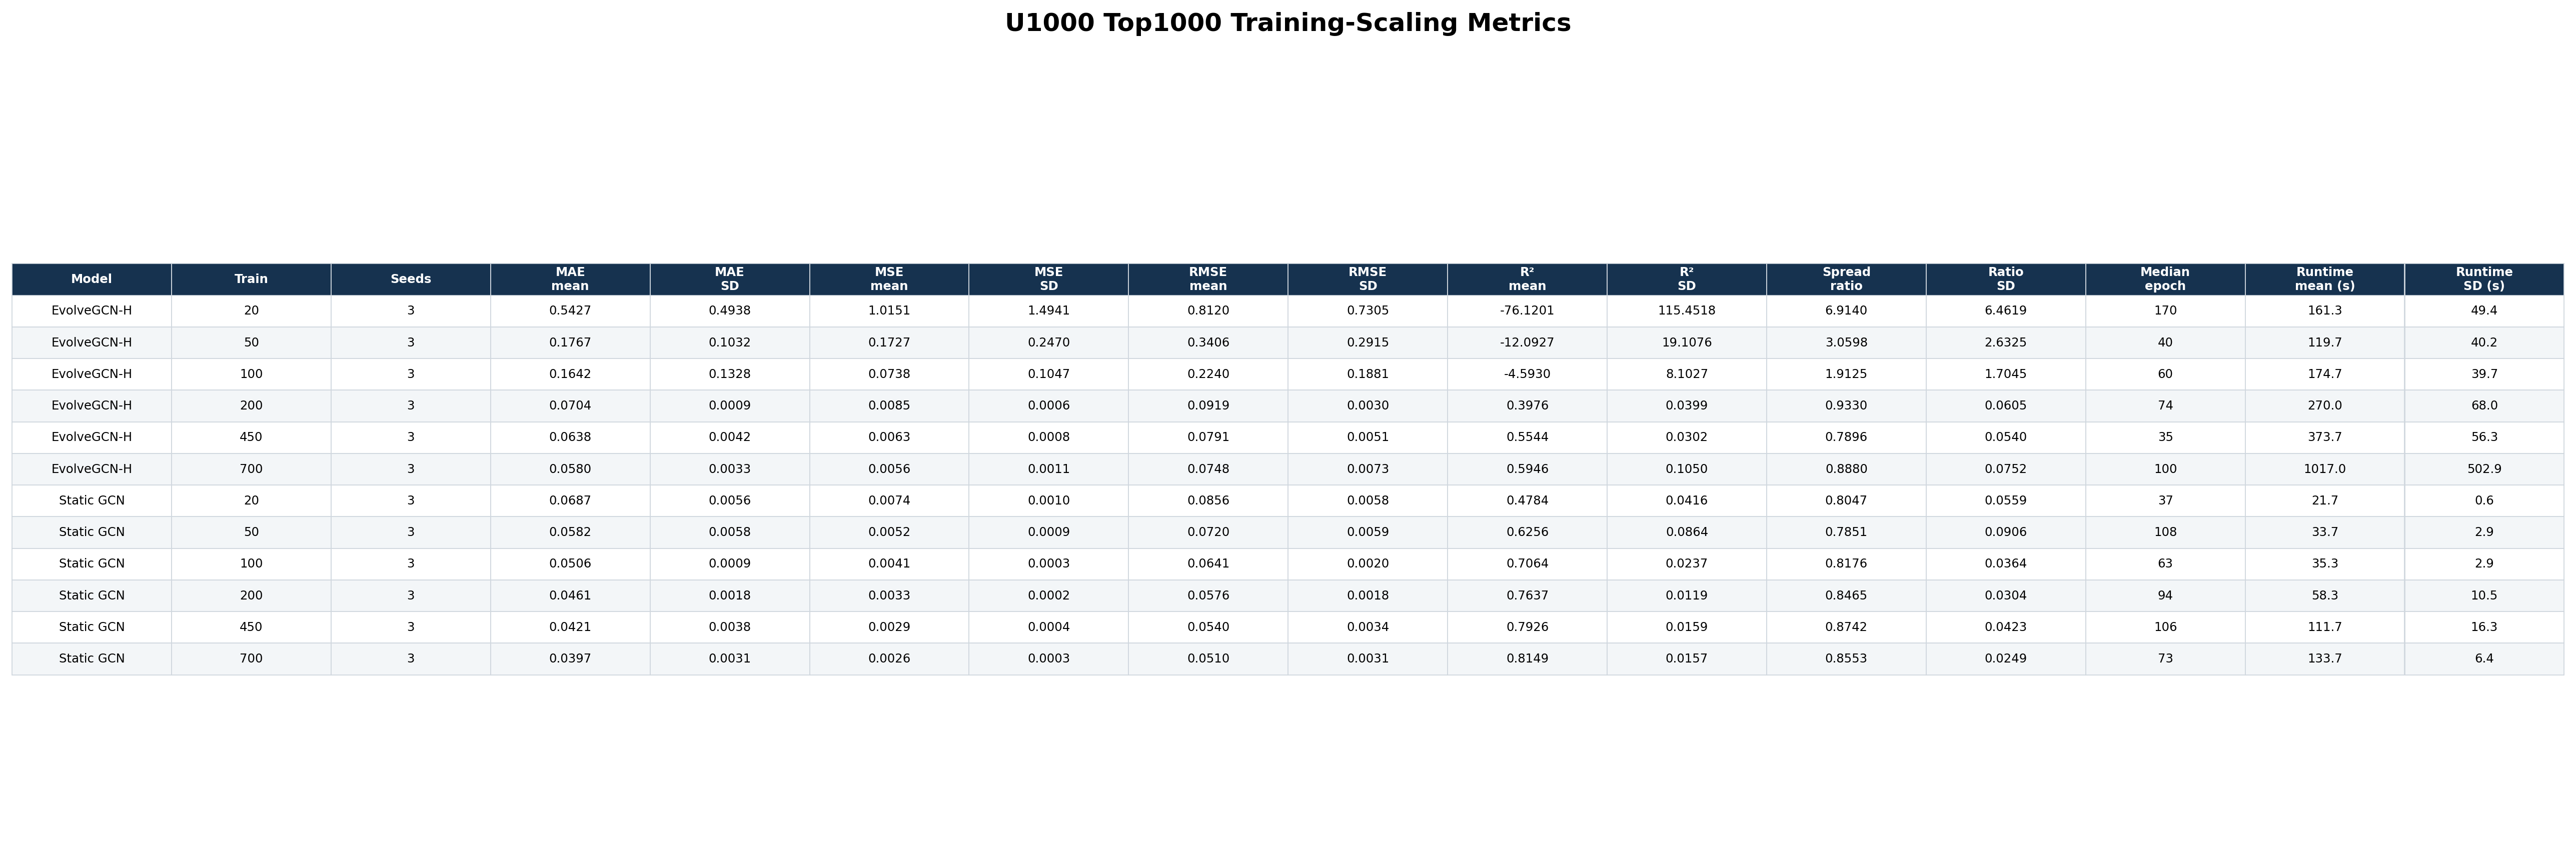

In [9]:
show_figure(
    ASSET_DIR / '14_main_metrics_table.png',
    'Validated static export of the complete main metrics table; the responsive table above remains the reproducible source-backed view.',
    width=1100,
)

Static GCN has the lower mean MAE at every training size. The most striking instability is Evolve Train20 (MAE $0.5427\pm0.4938$), where the sample SD is nearly as large as the mean. At Train700, Static reaches $0.0397\pm0.0031$ MAE and Evolve reaches $0.0580\pm0.0033$.

# 8 — How to Read a Training-Size Learning Curve

These are **not epoch-loss curves**. Each point is a fully trained model evaluated once on its held-out test set.

- **x-axis:** number of training universes.
- **y-axis:** test metric; lower is better for MAE/MSE/RMSE, higher is better for R².
- **point:** mean across seeds 42, 123, and 2025.
- **error bar:** sample standard deviation across those three seeds.

A large error bar at Train20 means that the three complete Train20 runs produced substantially different test results; it does not show uncertainty within an epoch. Symmetric MSE error bars may visually extend below zero even though MSE itself cannot be negative.

# 9 — Learning Curves

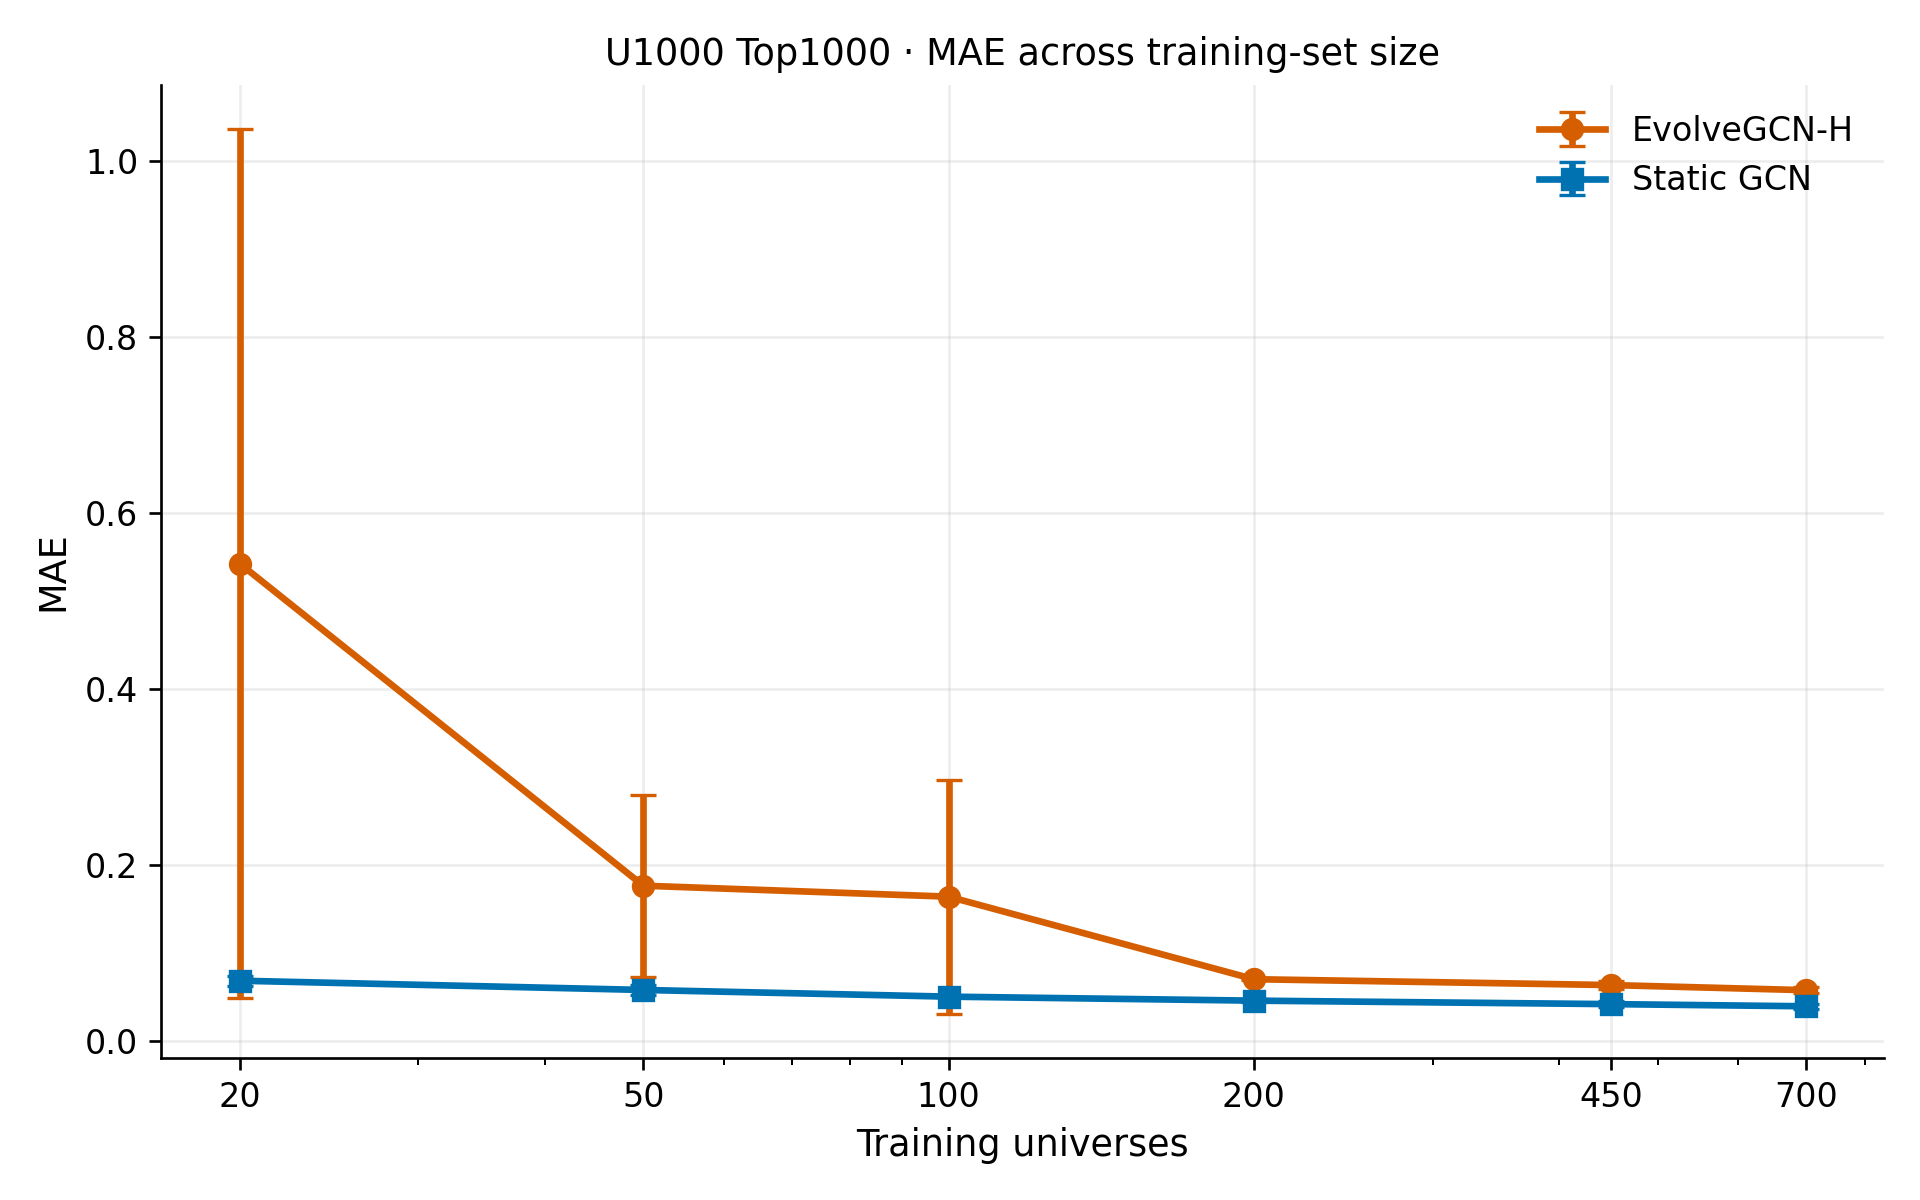

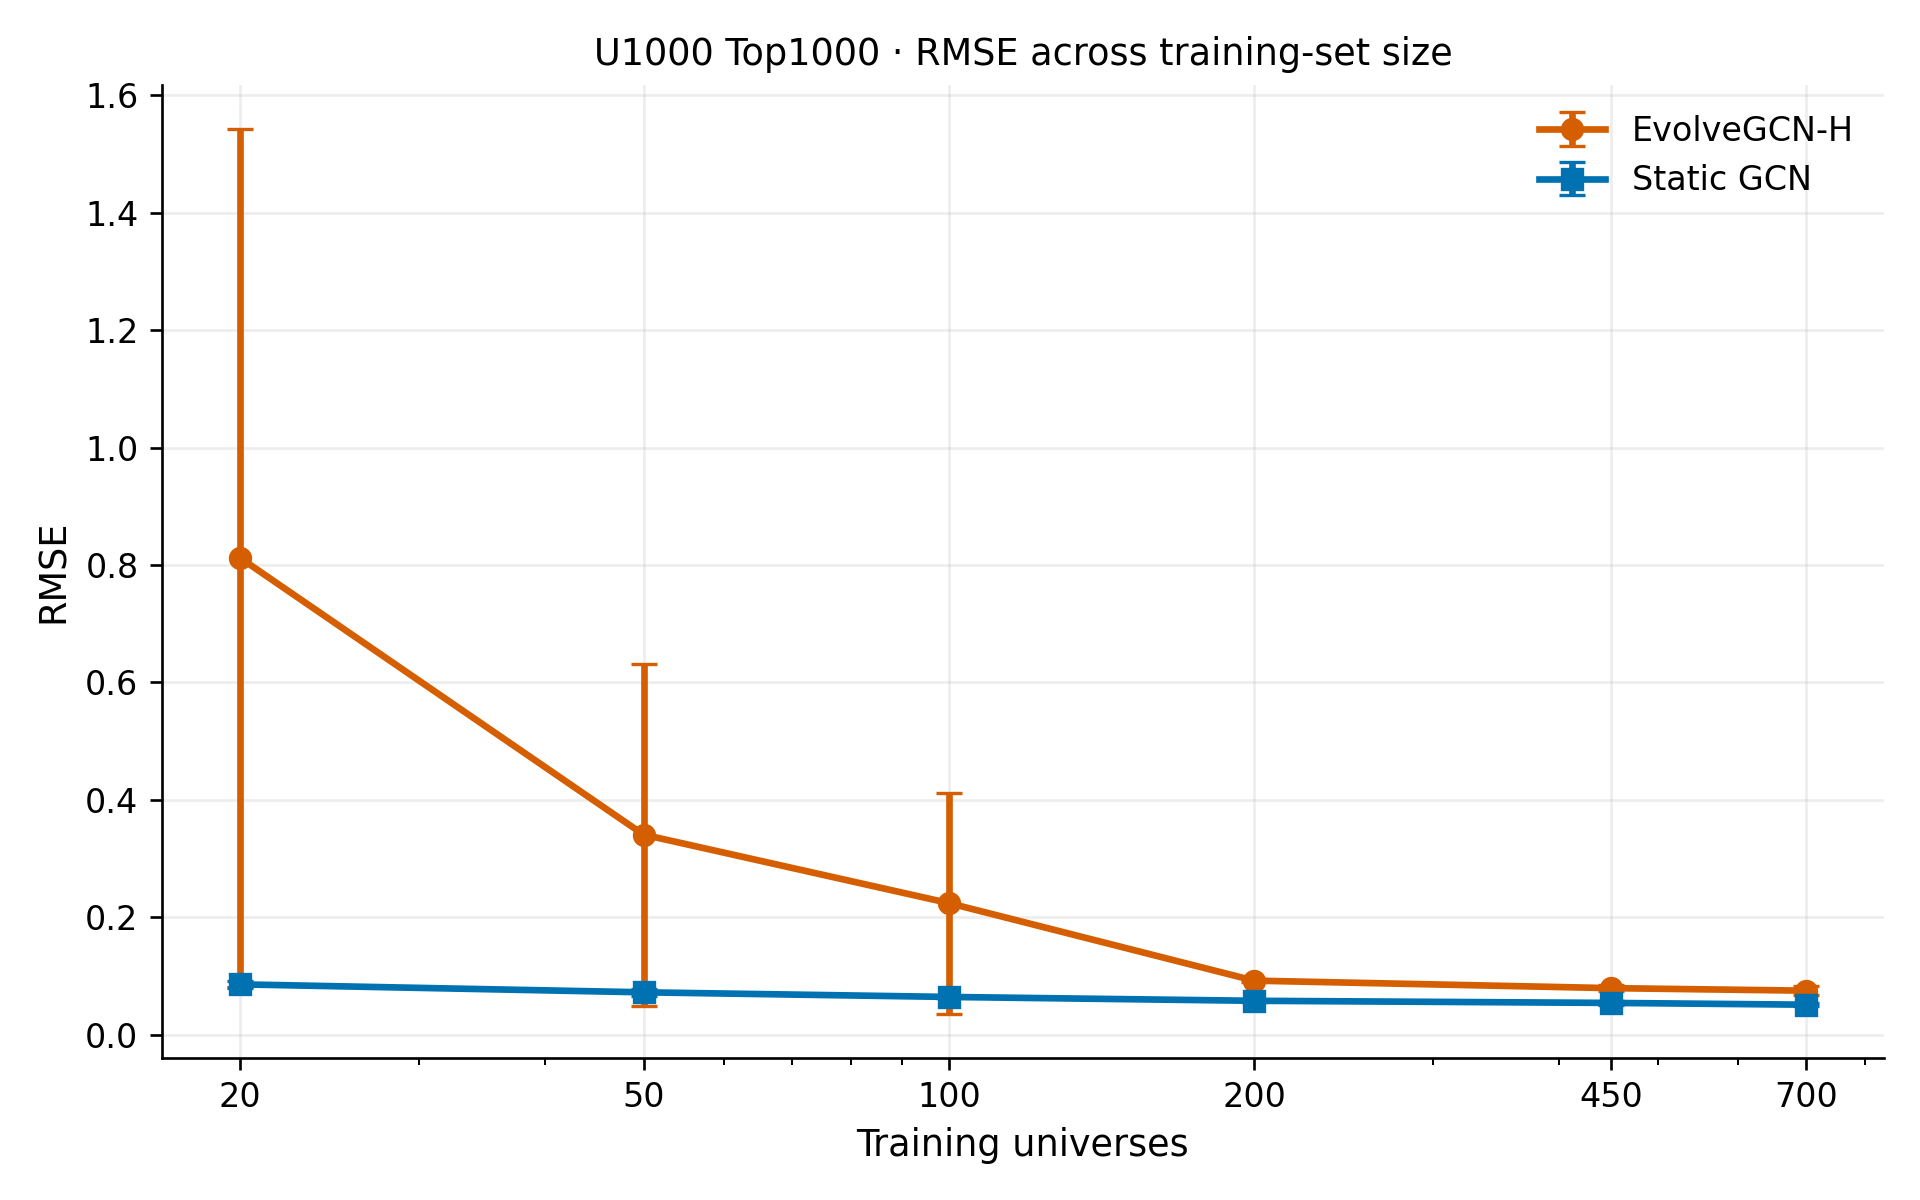

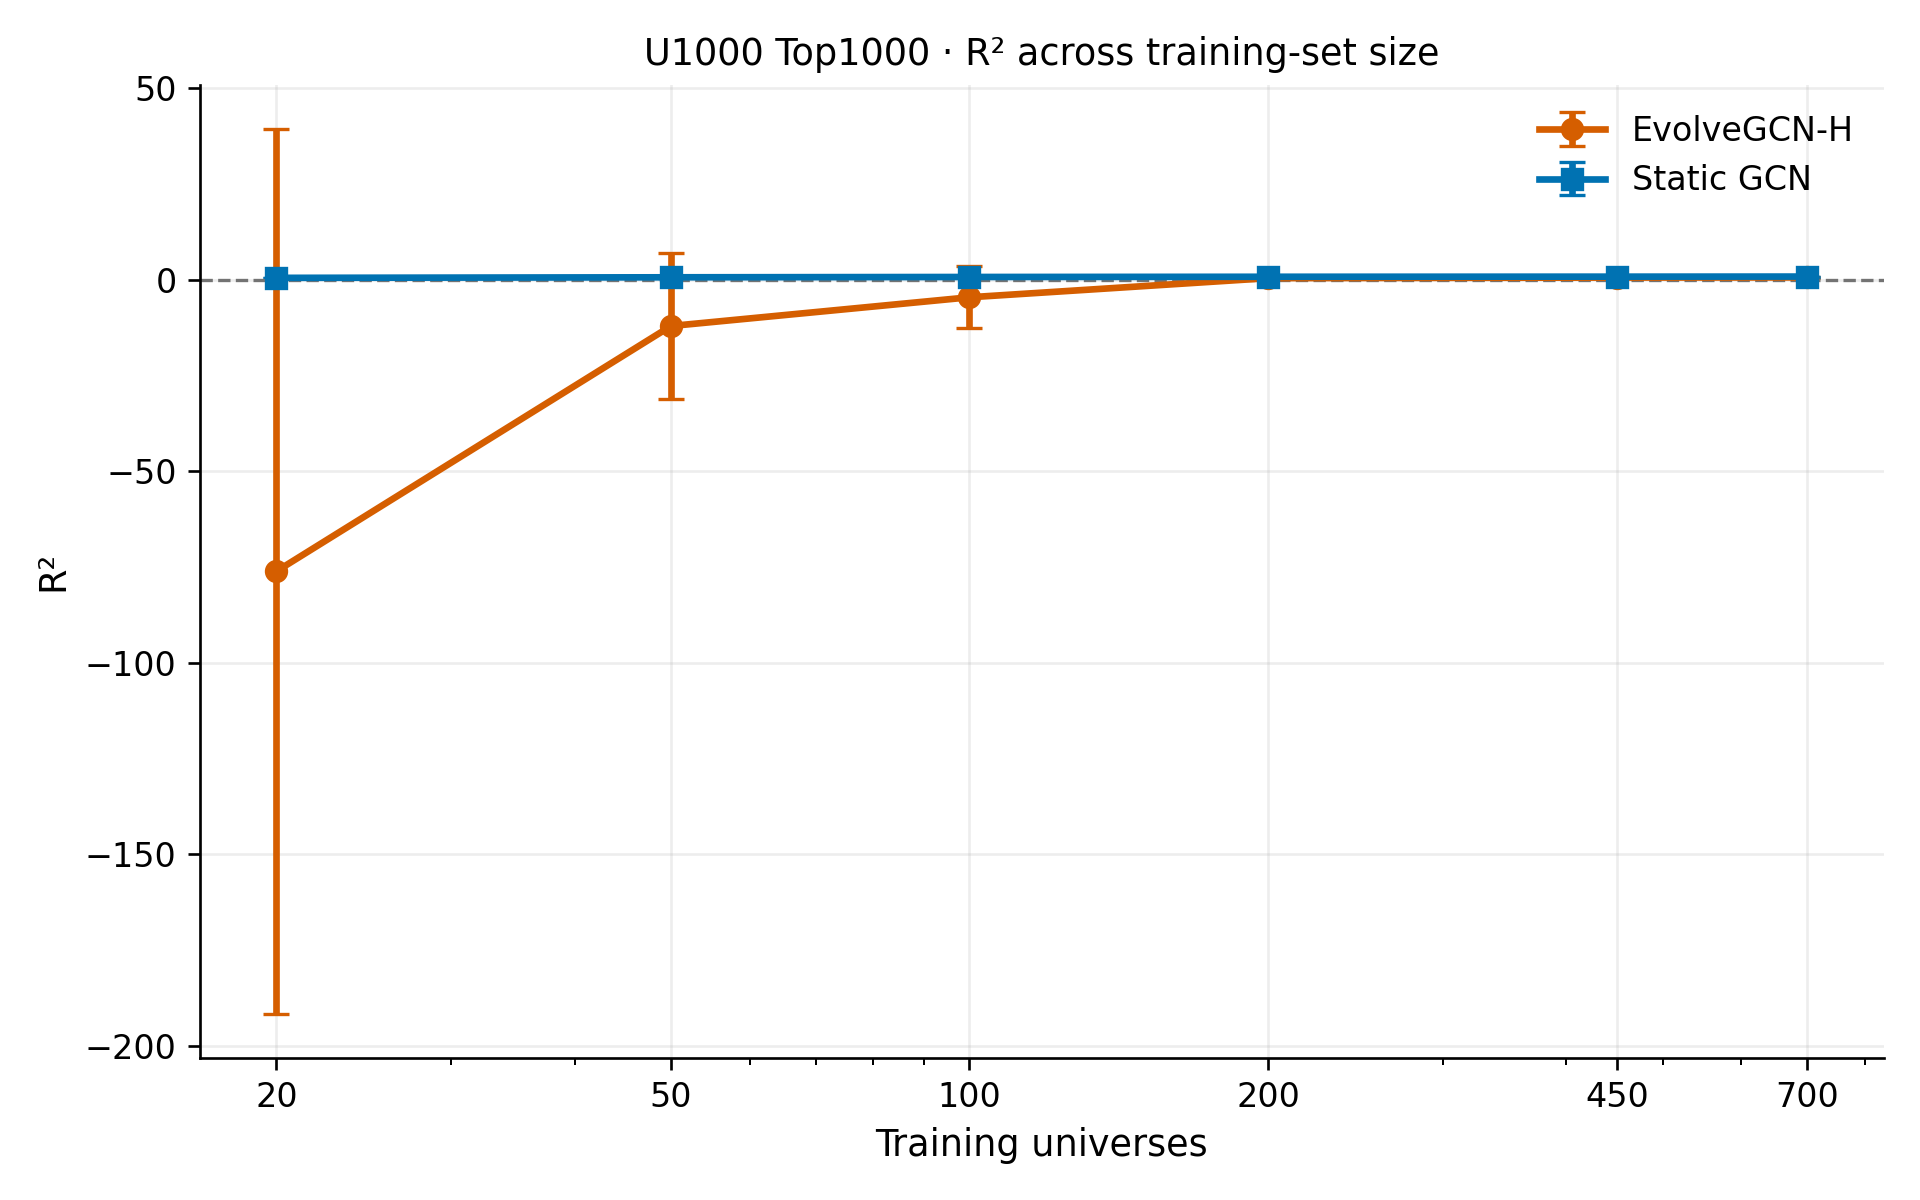

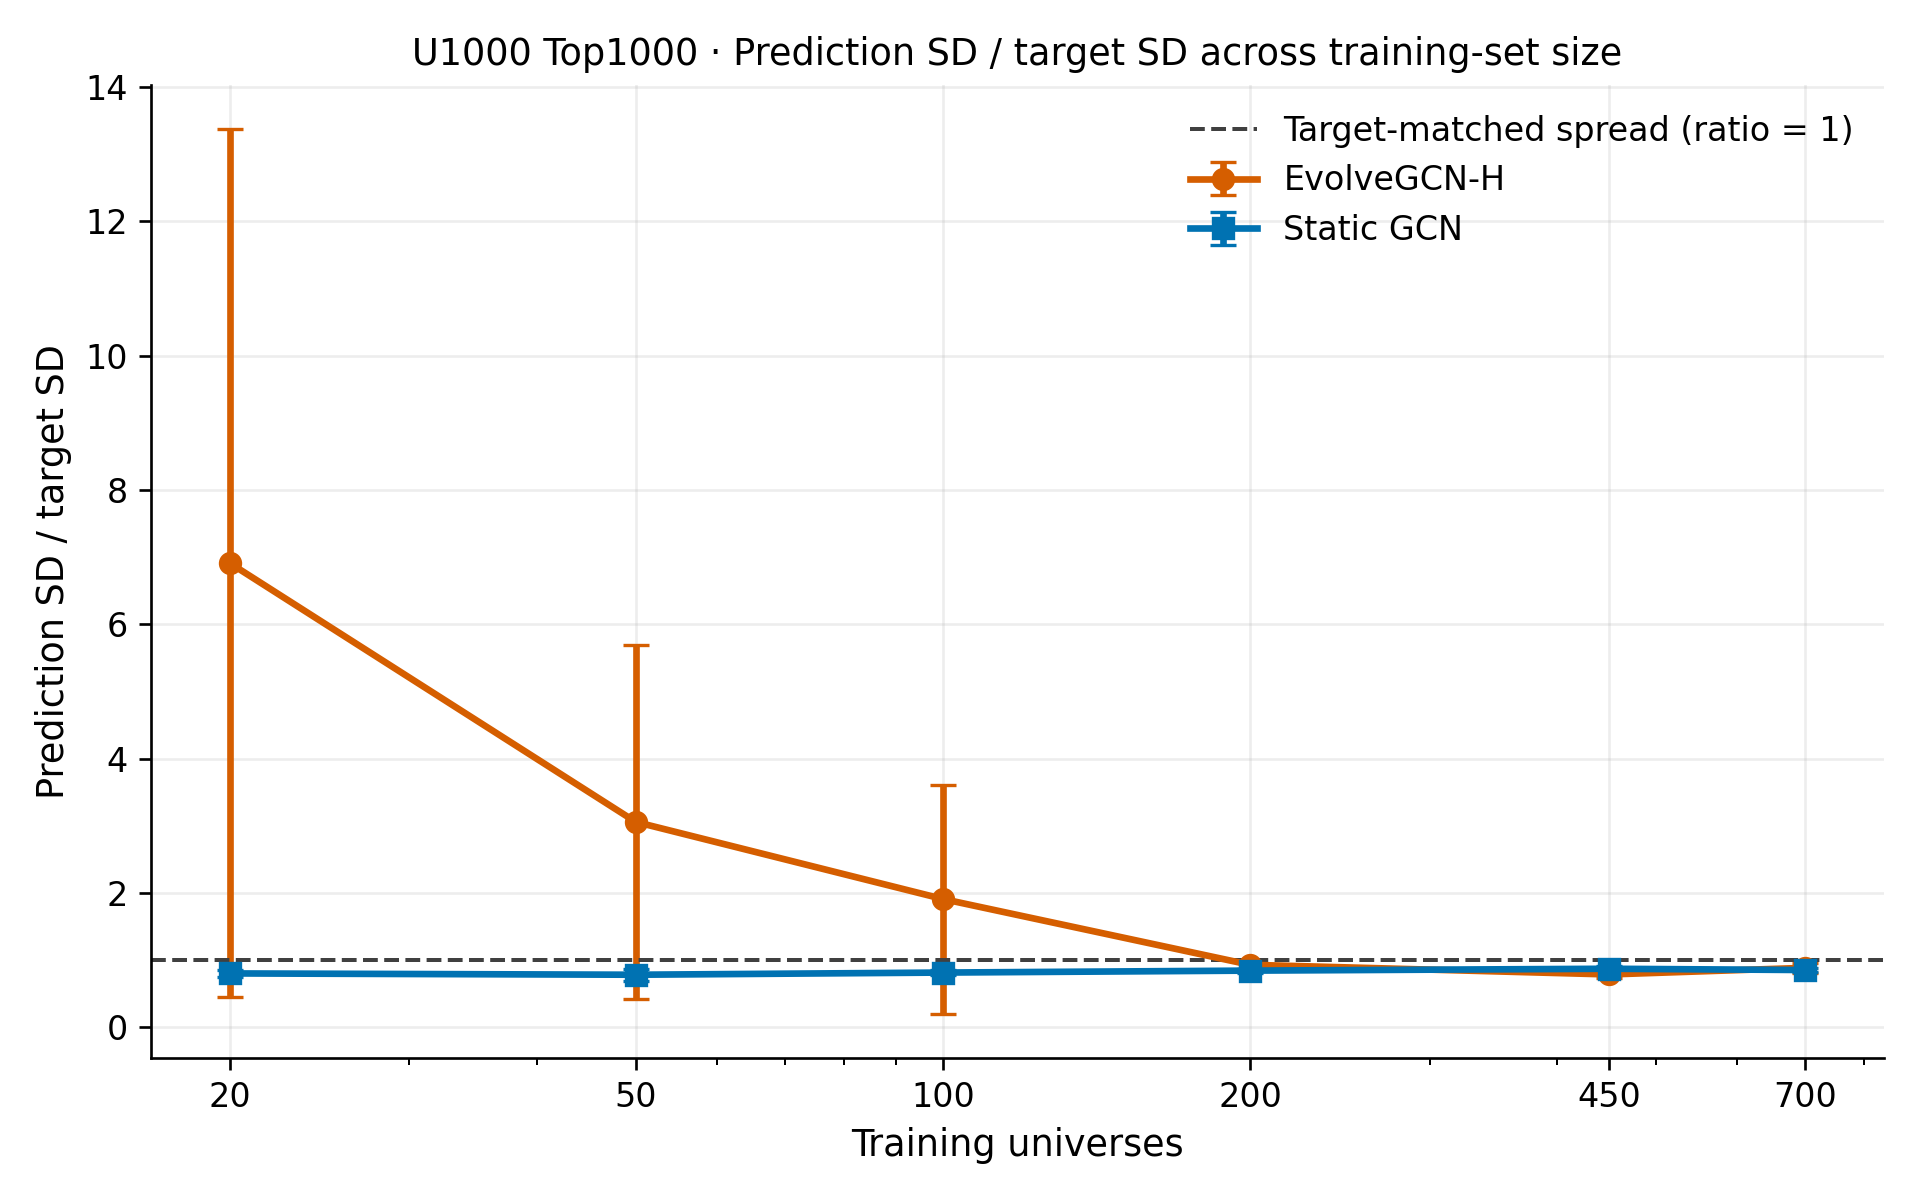

In [10]:
curve_assets = [
    ('08_mae_learning_curve.png', 'MAE learning curve'),
    ('09_rmse_learning_curve.png', 'RMSE learning curve'),
    ('10_r2_learning_curve.png', 'R² learning curve'),
    ('11_prediction_sd_ratio_curve.png', 'Prediction-SD ratio learning curve'),
]
for filename, caption in curve_assets:
    show_figure(ASSET_DIR / filename, caption + ' · points are three-seed means and error bars are sample SD.', width=980)

**Question.** Does more training data improve test performance and stability?  
**How to read.** Follow each model from left to right; compare vertical position and error-bar width.  
**Observation.** Both improve overall. Static improves smoothly and remains better at every level. Evolve is highly unstable at Train20–Train100, becomes reliable near Train200, and improves again from Train450 to Train700.  
**Interpretation.** Additional training universes help both architectures, with smaller late-stage gains; Static is more sample-efficient.  
**Next implication.** More universes alone do not close the architecture gap. These six points do not prove complete saturation.

# 10 — True versus Predicted $\Omega_m$

**Question.** Does each model recover individual held-out targets rather than only a central average?  
**How to read.** x is true $\Omega_m$, y is predicted $\Omega_m$, and the dashed identity line is perfect prediction. The objective is **not** for points to reach 0.8; it is for every point to lie near the identity line at its own true value. Each panel reports MAE, MSE, RMSE, and R².  
**Display policy.** The common presentation window emphasizes the physical target range. Off-window predictions are retained as boundary triangles and counted in-panel, so severe outliers are disclosed rather than silently removed.

In [11]:
def model_label(raw):
    return {'EvolveGCNHRegressor':'EvolveGCN-H', 'StaticGCNRegressor':'Static GCN'}[raw]

def prediction_path(model, size, seed):
    raw = 'EvolveGCNHRegressor' if model == 'EvolveGCN-H' else 'StaticGCNRegressor'
    row = run_matrix.query('model == @raw and training_universe_count == @size and seed == @seed').iloc[0]
    path = ROOT / row['experiment_directory'] / 'predictions/test_predictions.csv'
    if not path.is_file(): raise FileNotFoundError(path)
    return path

prediction_cache = {}
for size in SIZES:
    for model in MODELS:
        for seed in SEEDS:
            df = pd.read_csv(prediction_path(model, size, seed))
            assert len(df) == 201 and df['universe_id'].str.match(r'^LH_\d+$').all()
            df['residual'] = df['pred_omega_m'] - df['true_omega_m']
            prediction_cache[(model,size,seed)] = df

def make_true_predicted(size):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.2), sharex=True, sharey=True)
    colors = {'EvolveGCN-H':'#d95f02', 'Static GCN':'#0072B2'}
    ylo, yhi = 0.05, 0.55
    for row_idx, model in enumerate(MODELS):
        for col_idx, seed in enumerate(SEEDS):
            ax = axes[row_idx, col_idx]
            data = prediction_cache[(model,size,seed)]
            y = data['pred_omega_m'].to_numpy()
            clipped = np.clip(y, ylo, yhi)
            inside = (y >= ylo) & (y <= yhi)
            ax.scatter(data.loc[inside,'true_omega_m'], clipped[inside], s=17, alpha=.68, color=colors[model], edgecolor='none')
            low = y < ylo; high = y > yhi
            if low.any(): ax.scatter(data.loc[low,'true_omega_m'], clipped[low], marker='v', s=34, color=colors[model])
            if high.any(): ax.scatter(data.loc[high,'true_omega_m'], clipped[high], marker='^', s=34, color=colors[model])
            ax.plot([.08,.52],[.08,.52],'--',color='#333333',lw=1.4)
            metrics = per_run.query('model == @model and training_count == @size and seed == @seed').iloc[0]
            text = f"MAE {metrics.mae:.4f}\nMSE {metrics.mse:.4f}\nRMSE {metrics.rmse:.4f}\nR² {metrics.r2:.3f}"
            off = int((~inside).sum())
            if off: text += f'\n△/▽ off-window: {off}'
            ax.text(.03,.97,text,transform=ax.transAxes,va='top',fontsize=8.5,
                    bbox=dict(facecolor='white',edgecolor='#cbd5e1',alpha=.92))
            ax.set_title(f'{model} · seed {seed}')
            ax.set_xlim(.08,.52); ax.set_ylim(ylo,yhi); ax.grid(alpha=.2)
    fig.supxlabel(r'True $\Omega_m$'); fig.supylabel(r'Predicted $\Omega_m$')
    fig.suptitle(f'U1000 Top1000 · Train{size} true versus predicted $\Omega_m$', fontsize=16)
    fig.tight_layout(rect=[.02,.02,1,.96])
    path = OUTPUT_DIR / f'train{size}_true_vs_predicted_target_zoom.png'
    fig.savefig(path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return path

true_pred_paths = {size: make_true_predicted(size) for size in SIZES}
print('Generated deterministic target-range panels:', ', '.join(path.name for path in true_pred_paths.values()))

Generated deterministic target-range panels: train20_true_vs_predicted_target_zoom.png, train50_true_vs_predicted_target_zoom.png, train100_true_vs_predicted_target_zoom.png, train200_true_vs_predicted_target_zoom.png, train450_true_vs_predicted_target_zoom.png, train700_true_vs_predicted_target_zoom.png


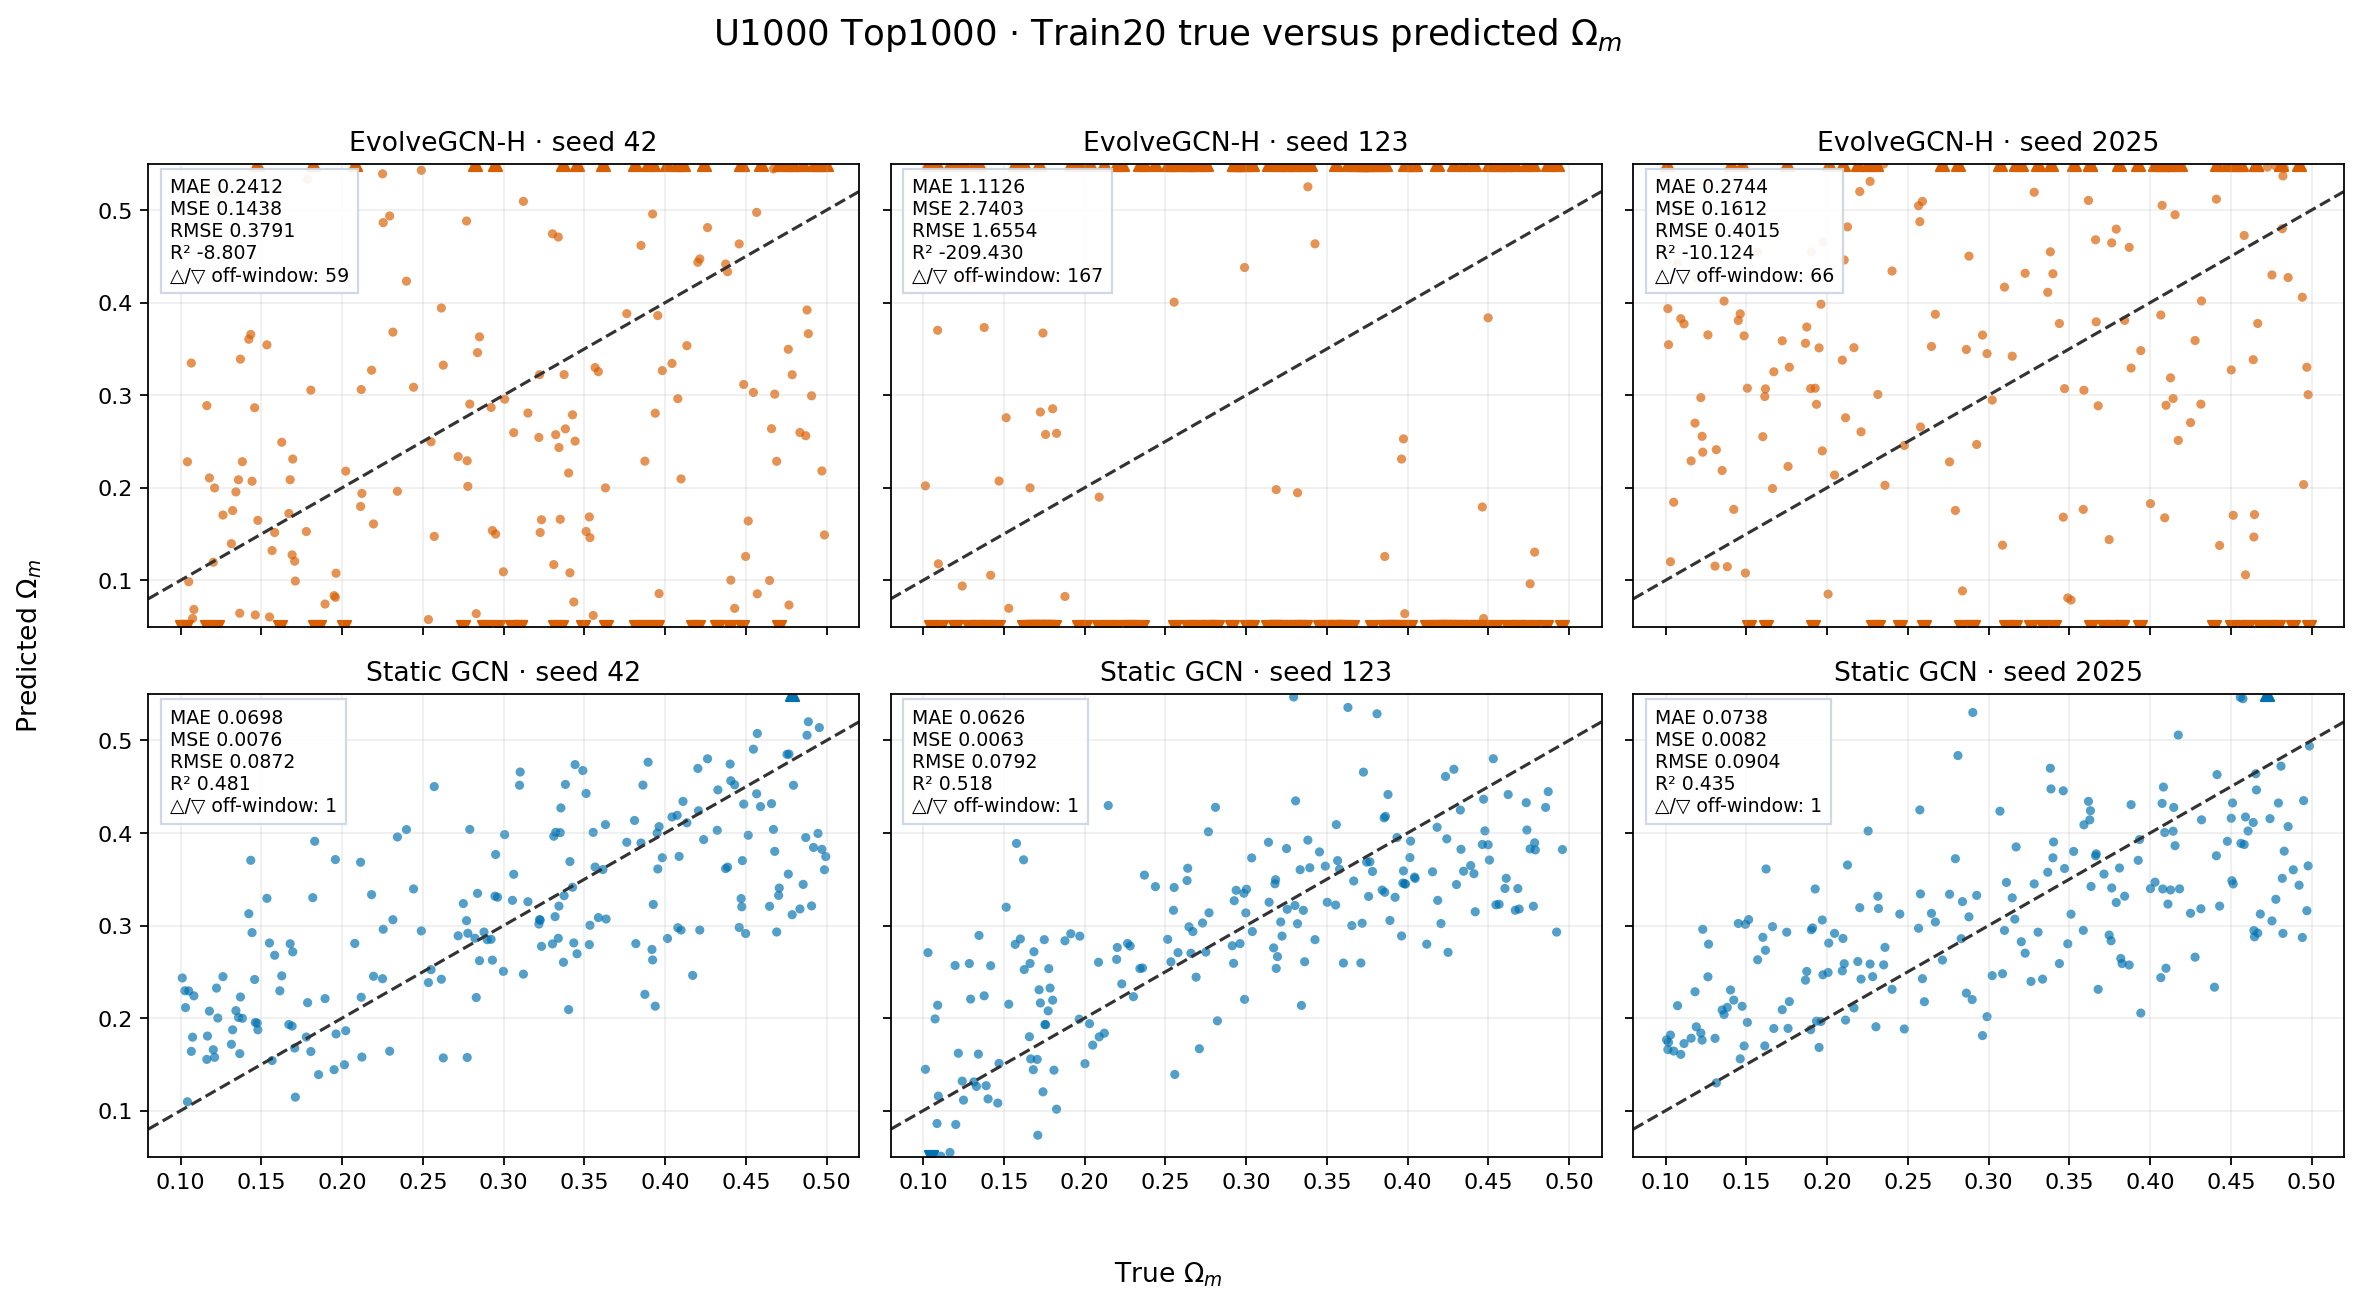

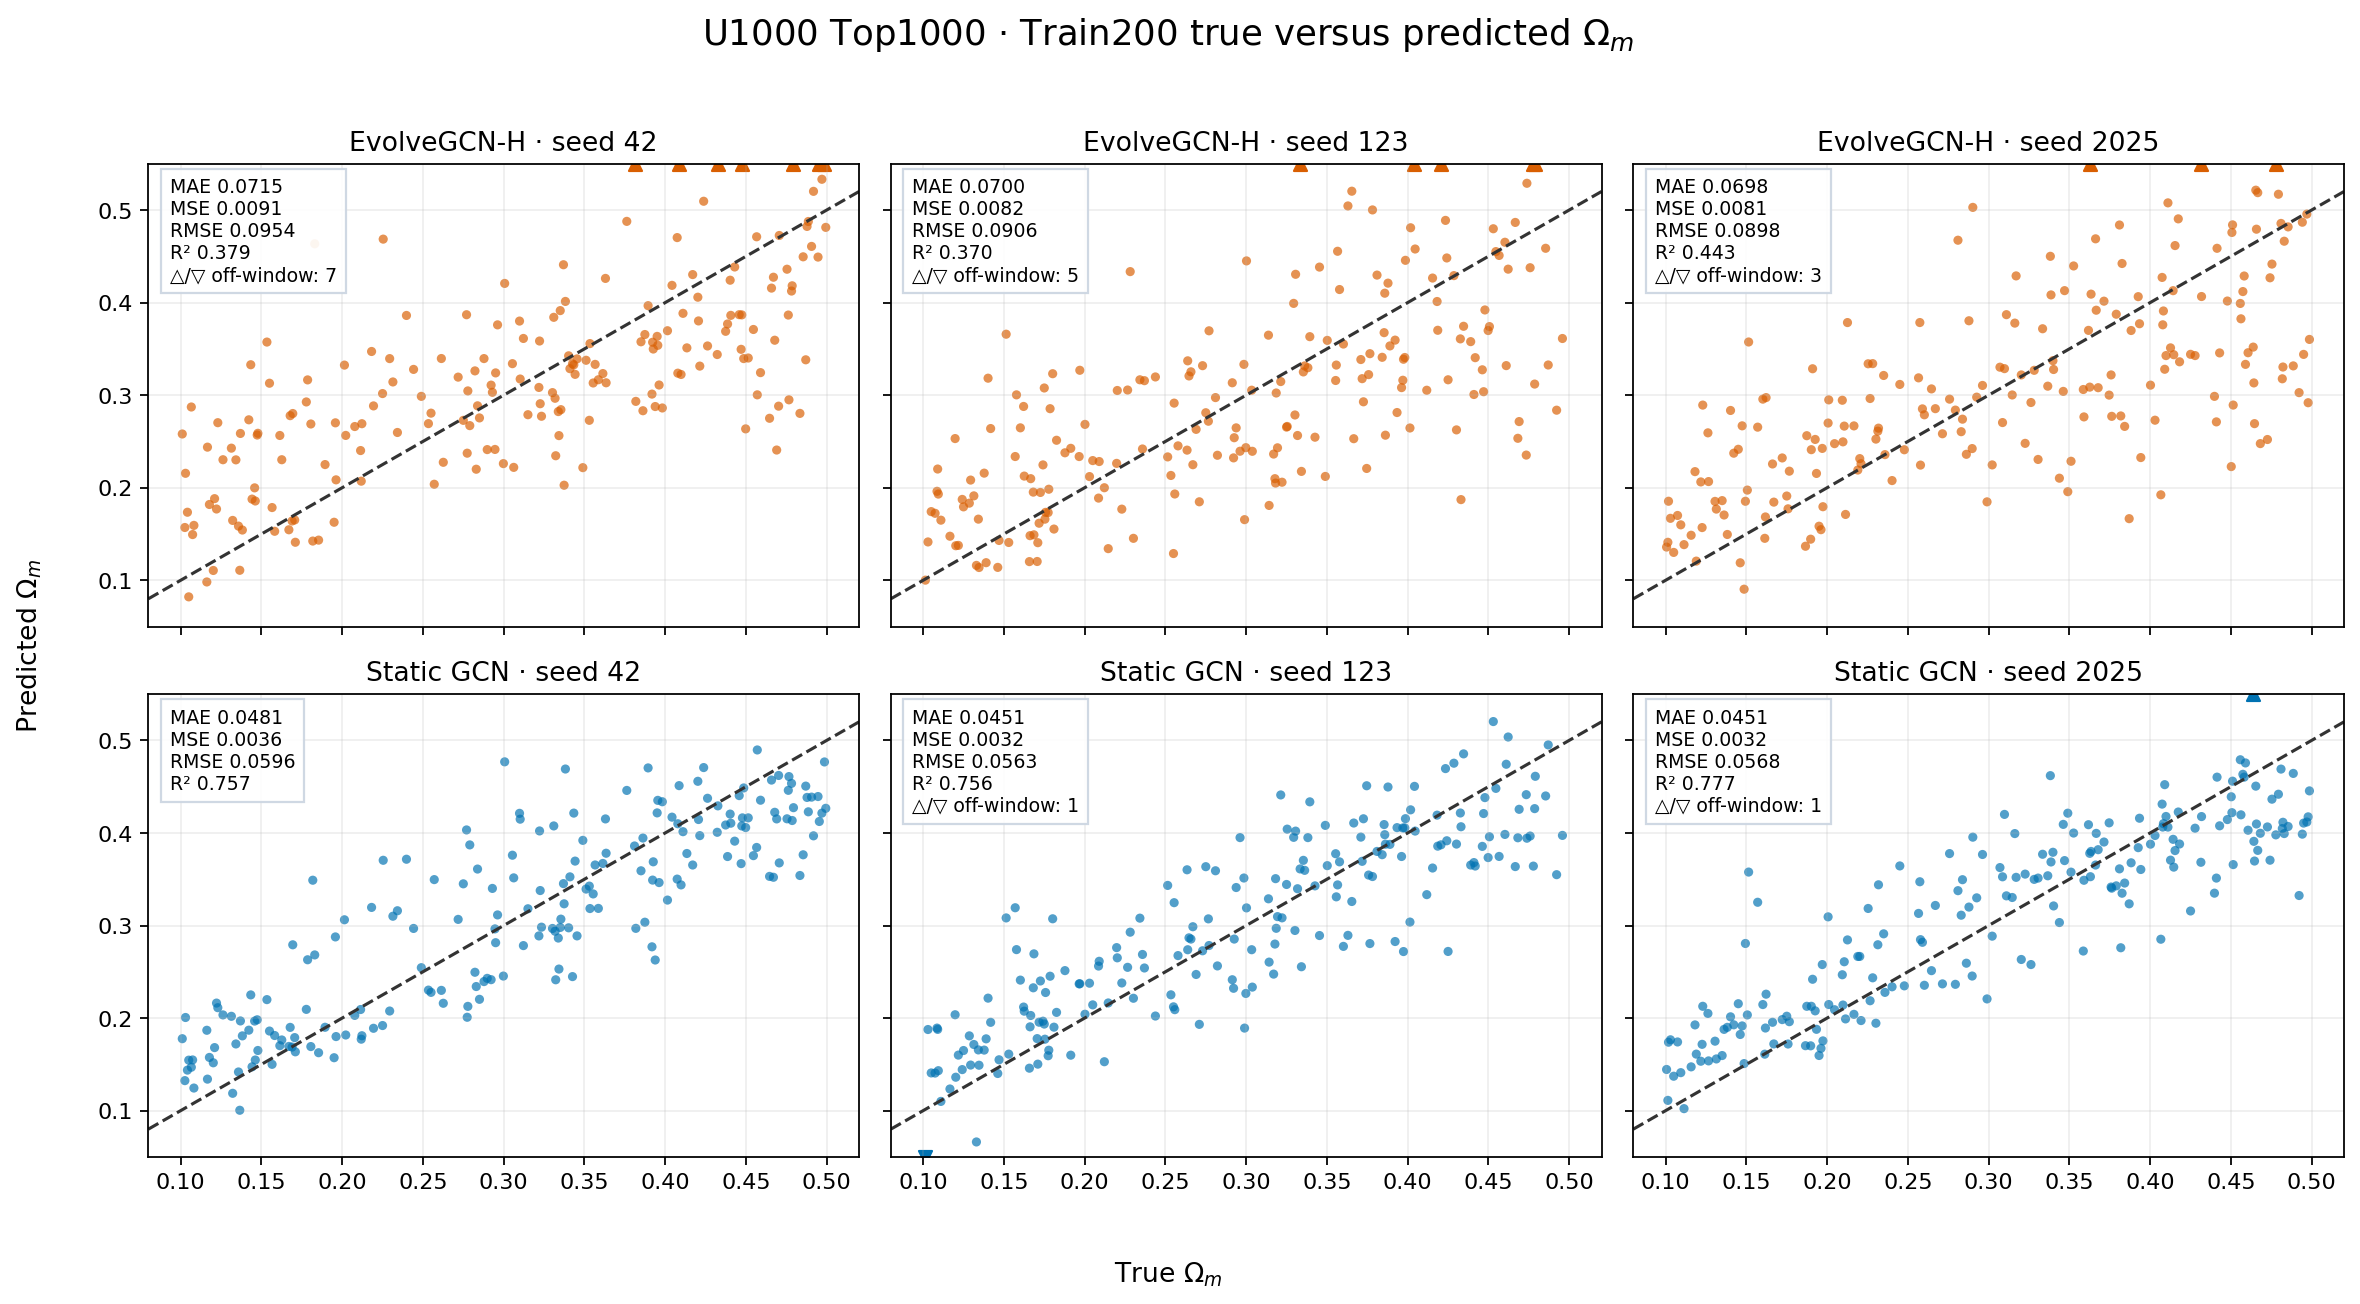

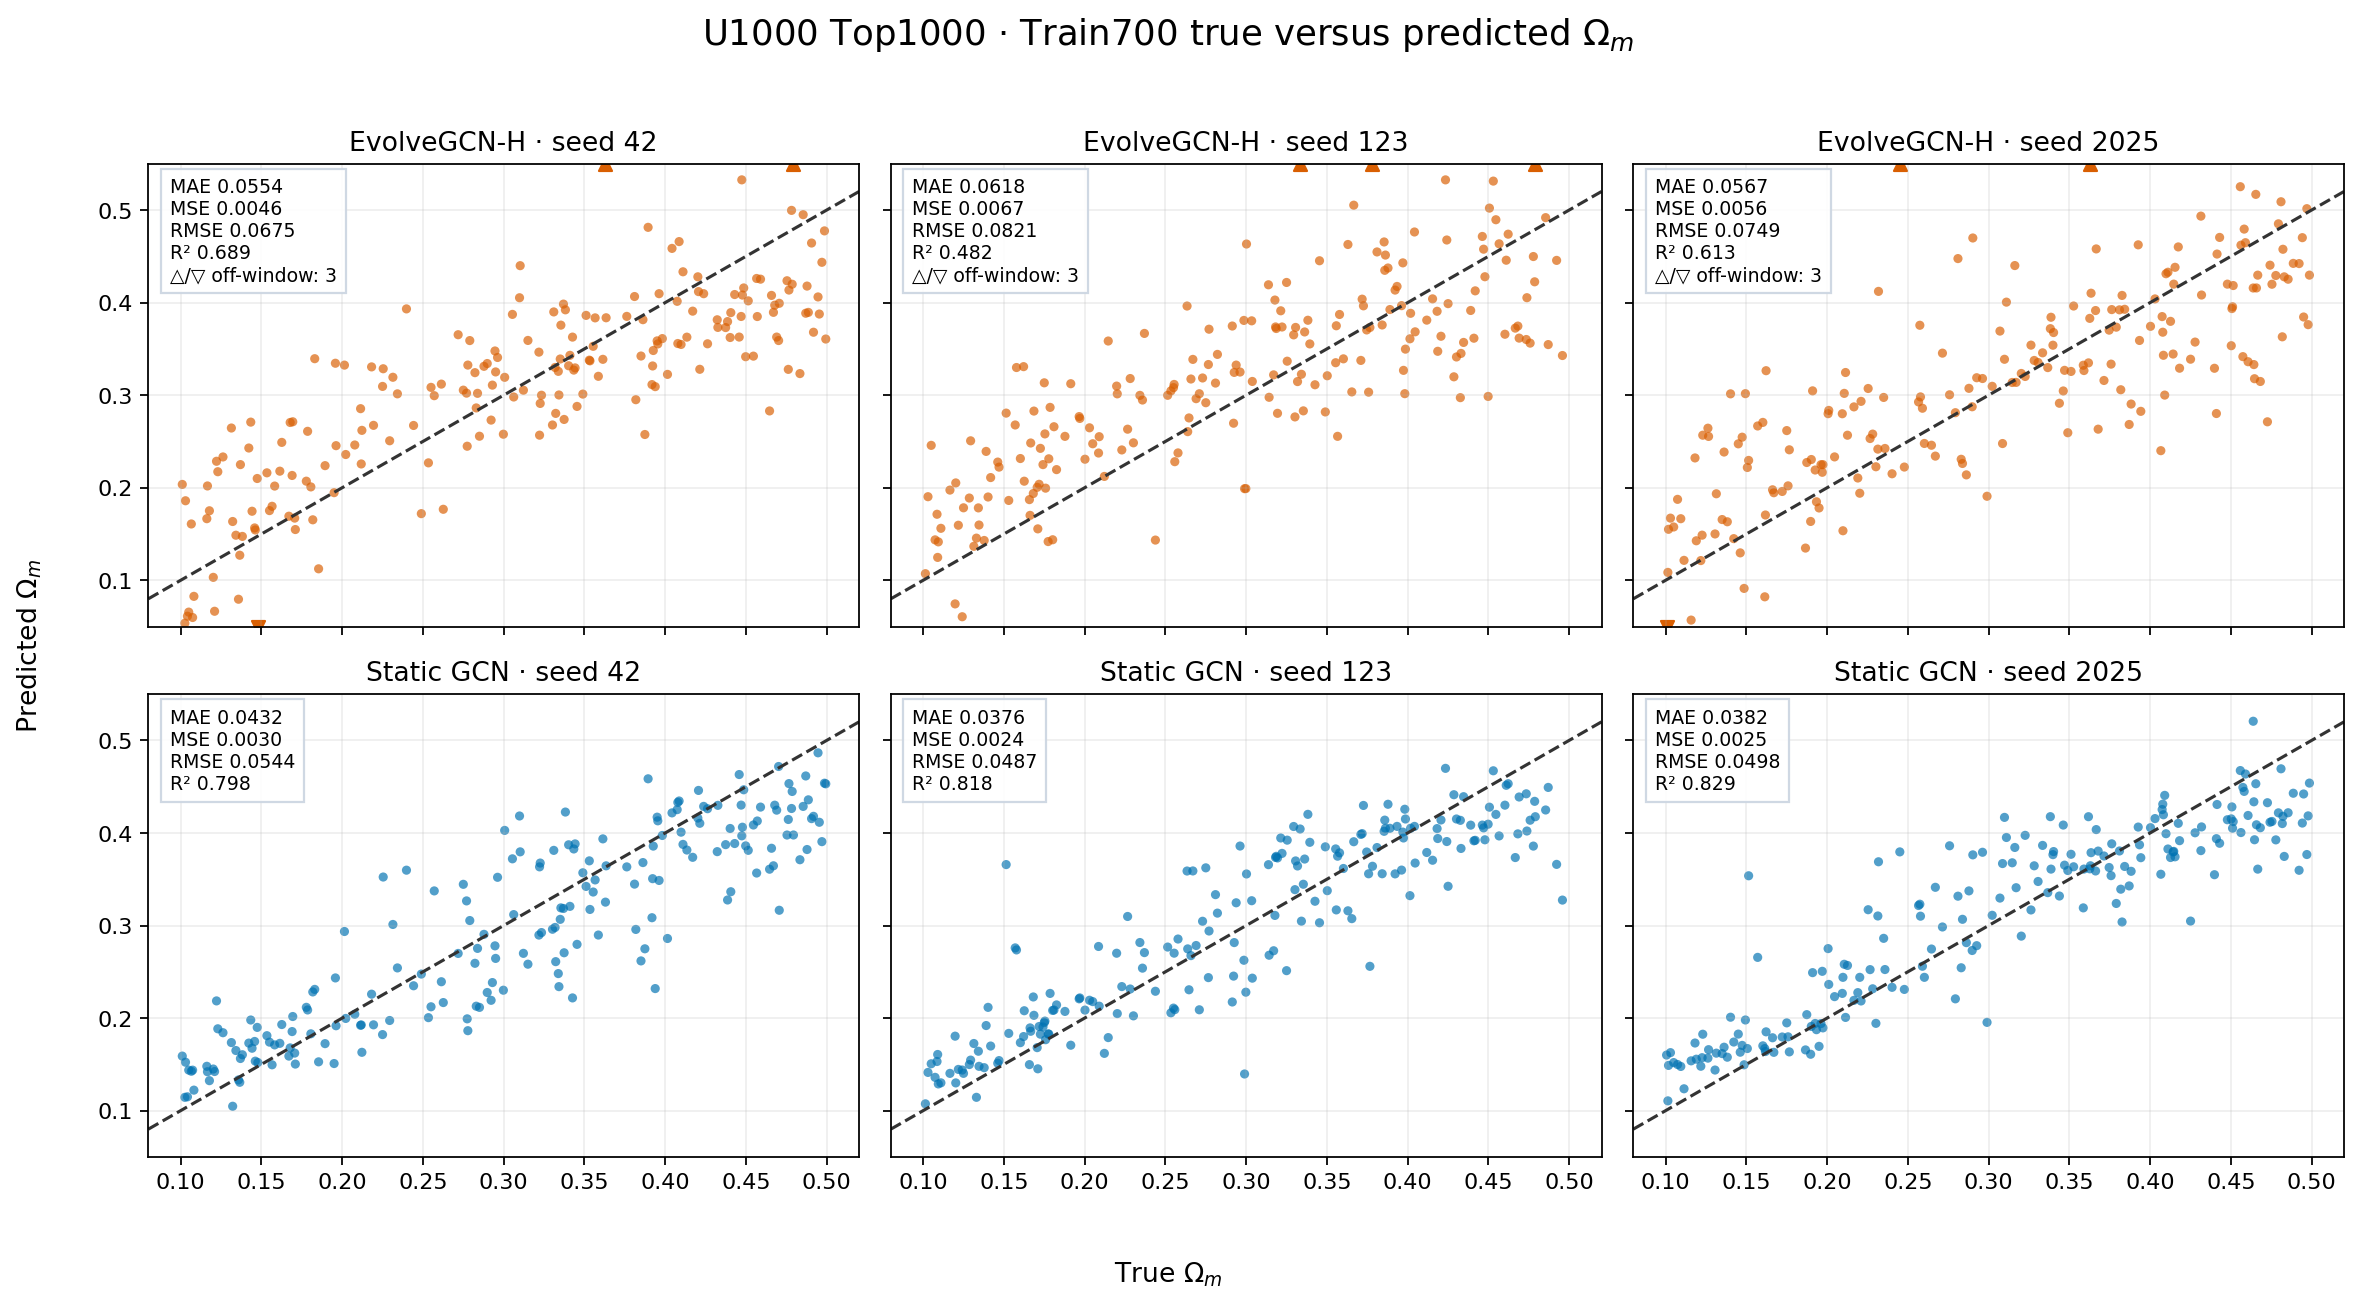

In [12]:
for size in [20, 200, 700]:
    show_figure(true_pred_paths[size], f'Train{size}: EvolveGCN-H (top) and Static GCN (bottom), seeds 42/123/2025.', width=1050)

**Observation.** Static follows the identity line more closely at all three representative sizes. Evolve Train20 is severely seed-dependent; by Train200 it is reliable but still more scattered than Static. At Train700 both discriminate targets, yet low values tend to be high and high values low.  
**Interpretation.** This is partial compression toward the central target range, not complete collapse at the larger sizes.  
**Not supported.** The panels do not establish that temporal information is inherently unhelpful; they compare complete architectures with different readouts and optimization behavior.

# 11 — Universe-Level Prediction Examples

In [13]:
def example_rows(data):
    work = data.copy()
    groups = [
        ('Best predicted', work.nsmallest(5, 'absolute_error')),
        ('Worst predicted', work.nlargest(5, 'absolute_error')),
        ('Lowest target', work.nsmallest(5, 'true_omega_m')),
        ('Highest target', work.nlargest(5, 'true_omega_m')),
    ]
    out = pd.concat([frame.assign(Category=label) for label, frame in groups], ignore_index=True)
    return out[['Category','universe_id','true_omega_m','pred_omega_m','residual','absolute_error']]

parts = []
for model in MODELS:
    for seed in SEEDS:
        table = example_rows(prediction_cache[(model,700,seed)]).copy()
        for col in ['true_omega_m','pred_omega_m','residual','absolute_error']:
            table[col] = table[col].map(lambda x: f'{x:.5f}')
        parts.append(f'<details><summary>{escape(model)} · Train700 · seed {seed} — 20 selected universes</summary>' +
                     table.to_html(index=False, escape=True) + '</details>')
display(HTML(''.join(parts)))

Category,universe_id,true_omega_m,pred_omega_m,residual,absolute_error
Best predicted,LH_570,0.19500,0.19466,-0.00034,0.00034
Best predicted,LH_238,0.33180,0.32990,-0.00190,0.00190
Best predicted,LH_405,0.34100,0.34302,0.00202,0.00202
Best predicted,LH_156,0.16700,0.16923,0.00223,0.00223
Best predicted,LH_588,0.35540,0.35276,-0.00264,0.00264
Worst predicted,LH_643,0.36300,0.55130,0.18830,0.18830
Worst predicted,LH_486,0.46460,0.28296,-0.18164,0.18164
Worst predicted,LH_657,0.48340,0.32331,-0.16009,0.16009
Worst predicted,LH_273,0.18300,0.33938,0.15638,0.15638
Worst predicted,LH_3,0.23980,0.39318,0.15338,0.15338


These tables use the exact `LH_x` IDs from saved test prediction files. They expose good fits, large errors, and both target extremes without annotating all 201 scatter points. Different seeds have different test populations, so no scientifically invalid per-universe cross-seed average is constructed.

# 12 — Lowest-to-Highest $\Omega_m$

**Question.** Do predictions track the ordered target trend?  
**How to read.** Test universes are sorted by true $\Omega_m$; predicted lines should follow the same increasing pattern.  
**Observation.** Low targets tend to be predicted too high and high targets too low.  
**Interpretation.** The narrowing relative to the truth is regression toward the mean. The exact `LH_x` identities remain available in the companion tables above and Appendix A/C.

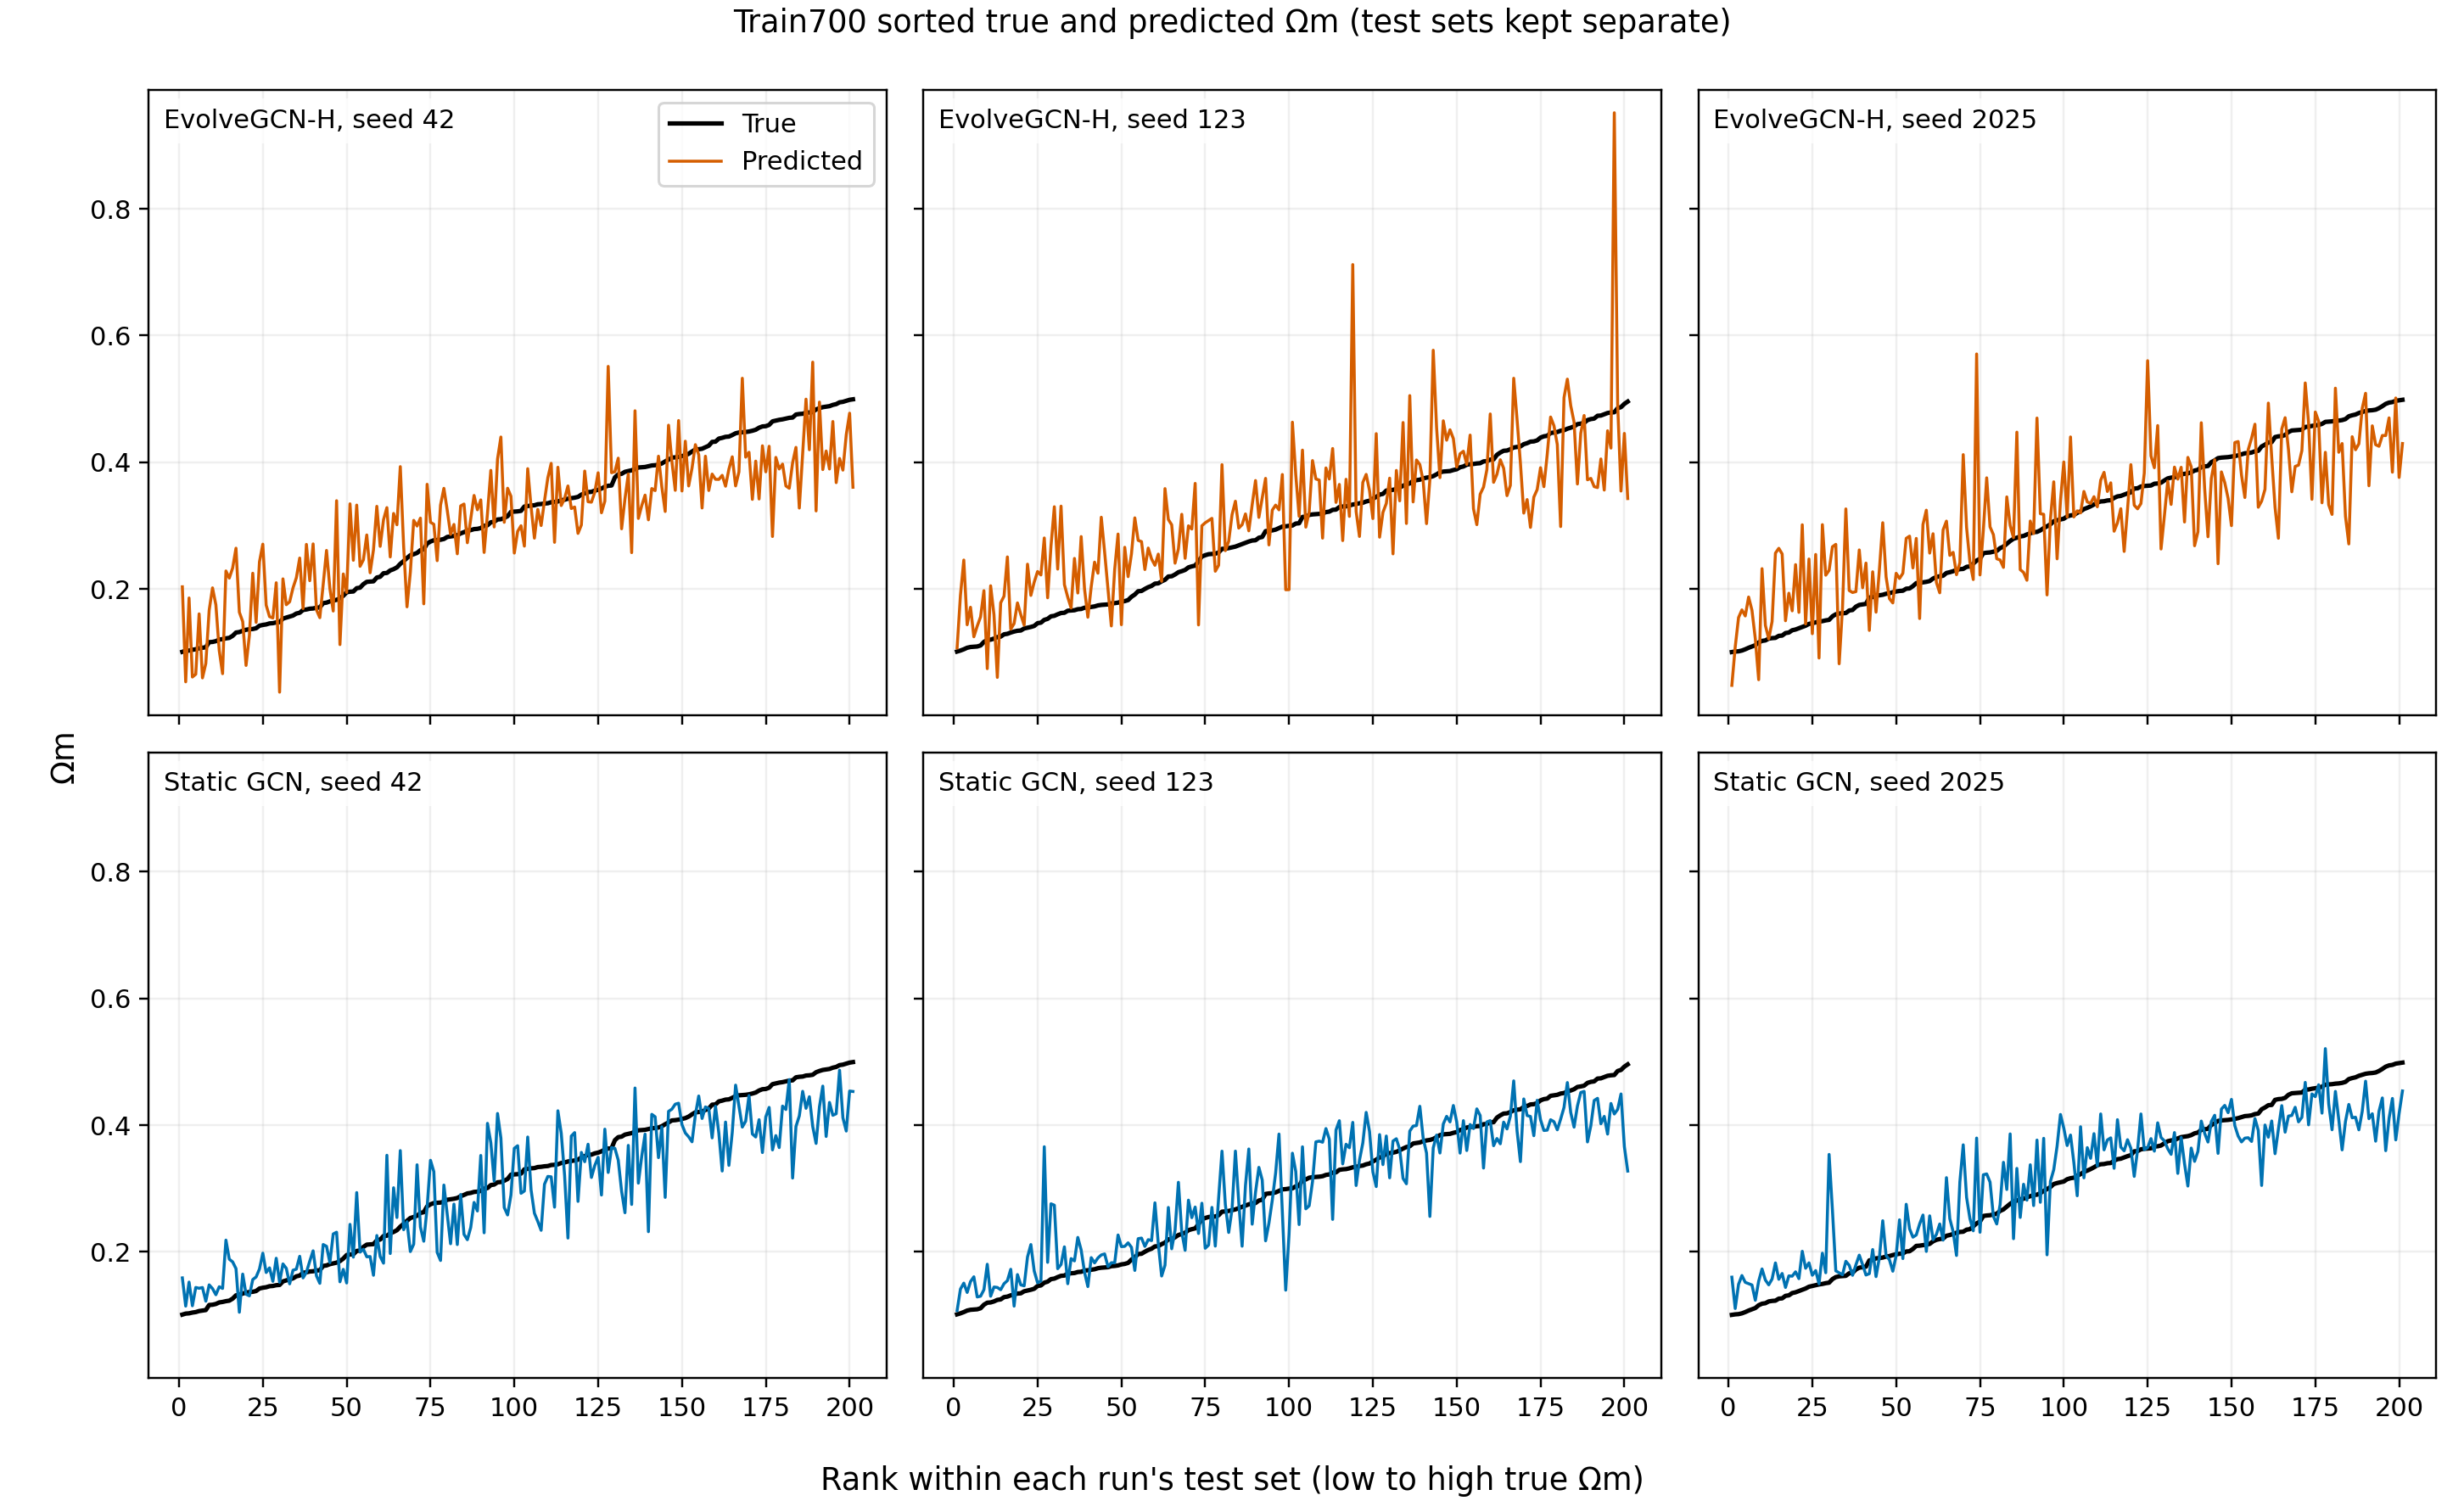

In [14]:
show_figure(ASSET_DIR / '07_train700_sorted_low_to_high_omega_m.png', 'Train700 predictions sorted independently within each valid seed-specific test population.', width=1020)

# 13 — Residual and Compression Analysis

The residual is

$$r_i = \widehat{\Omega}_{m,i} - \Omega_{m,i}.$$

A positive residual is overprediction; a negative residual is underprediction. Complete collapse would produce nearly constant predictions. Partial compression preserves ordering but with too little spread; successful discrimination produces predictions that vary meaningfully with the target.

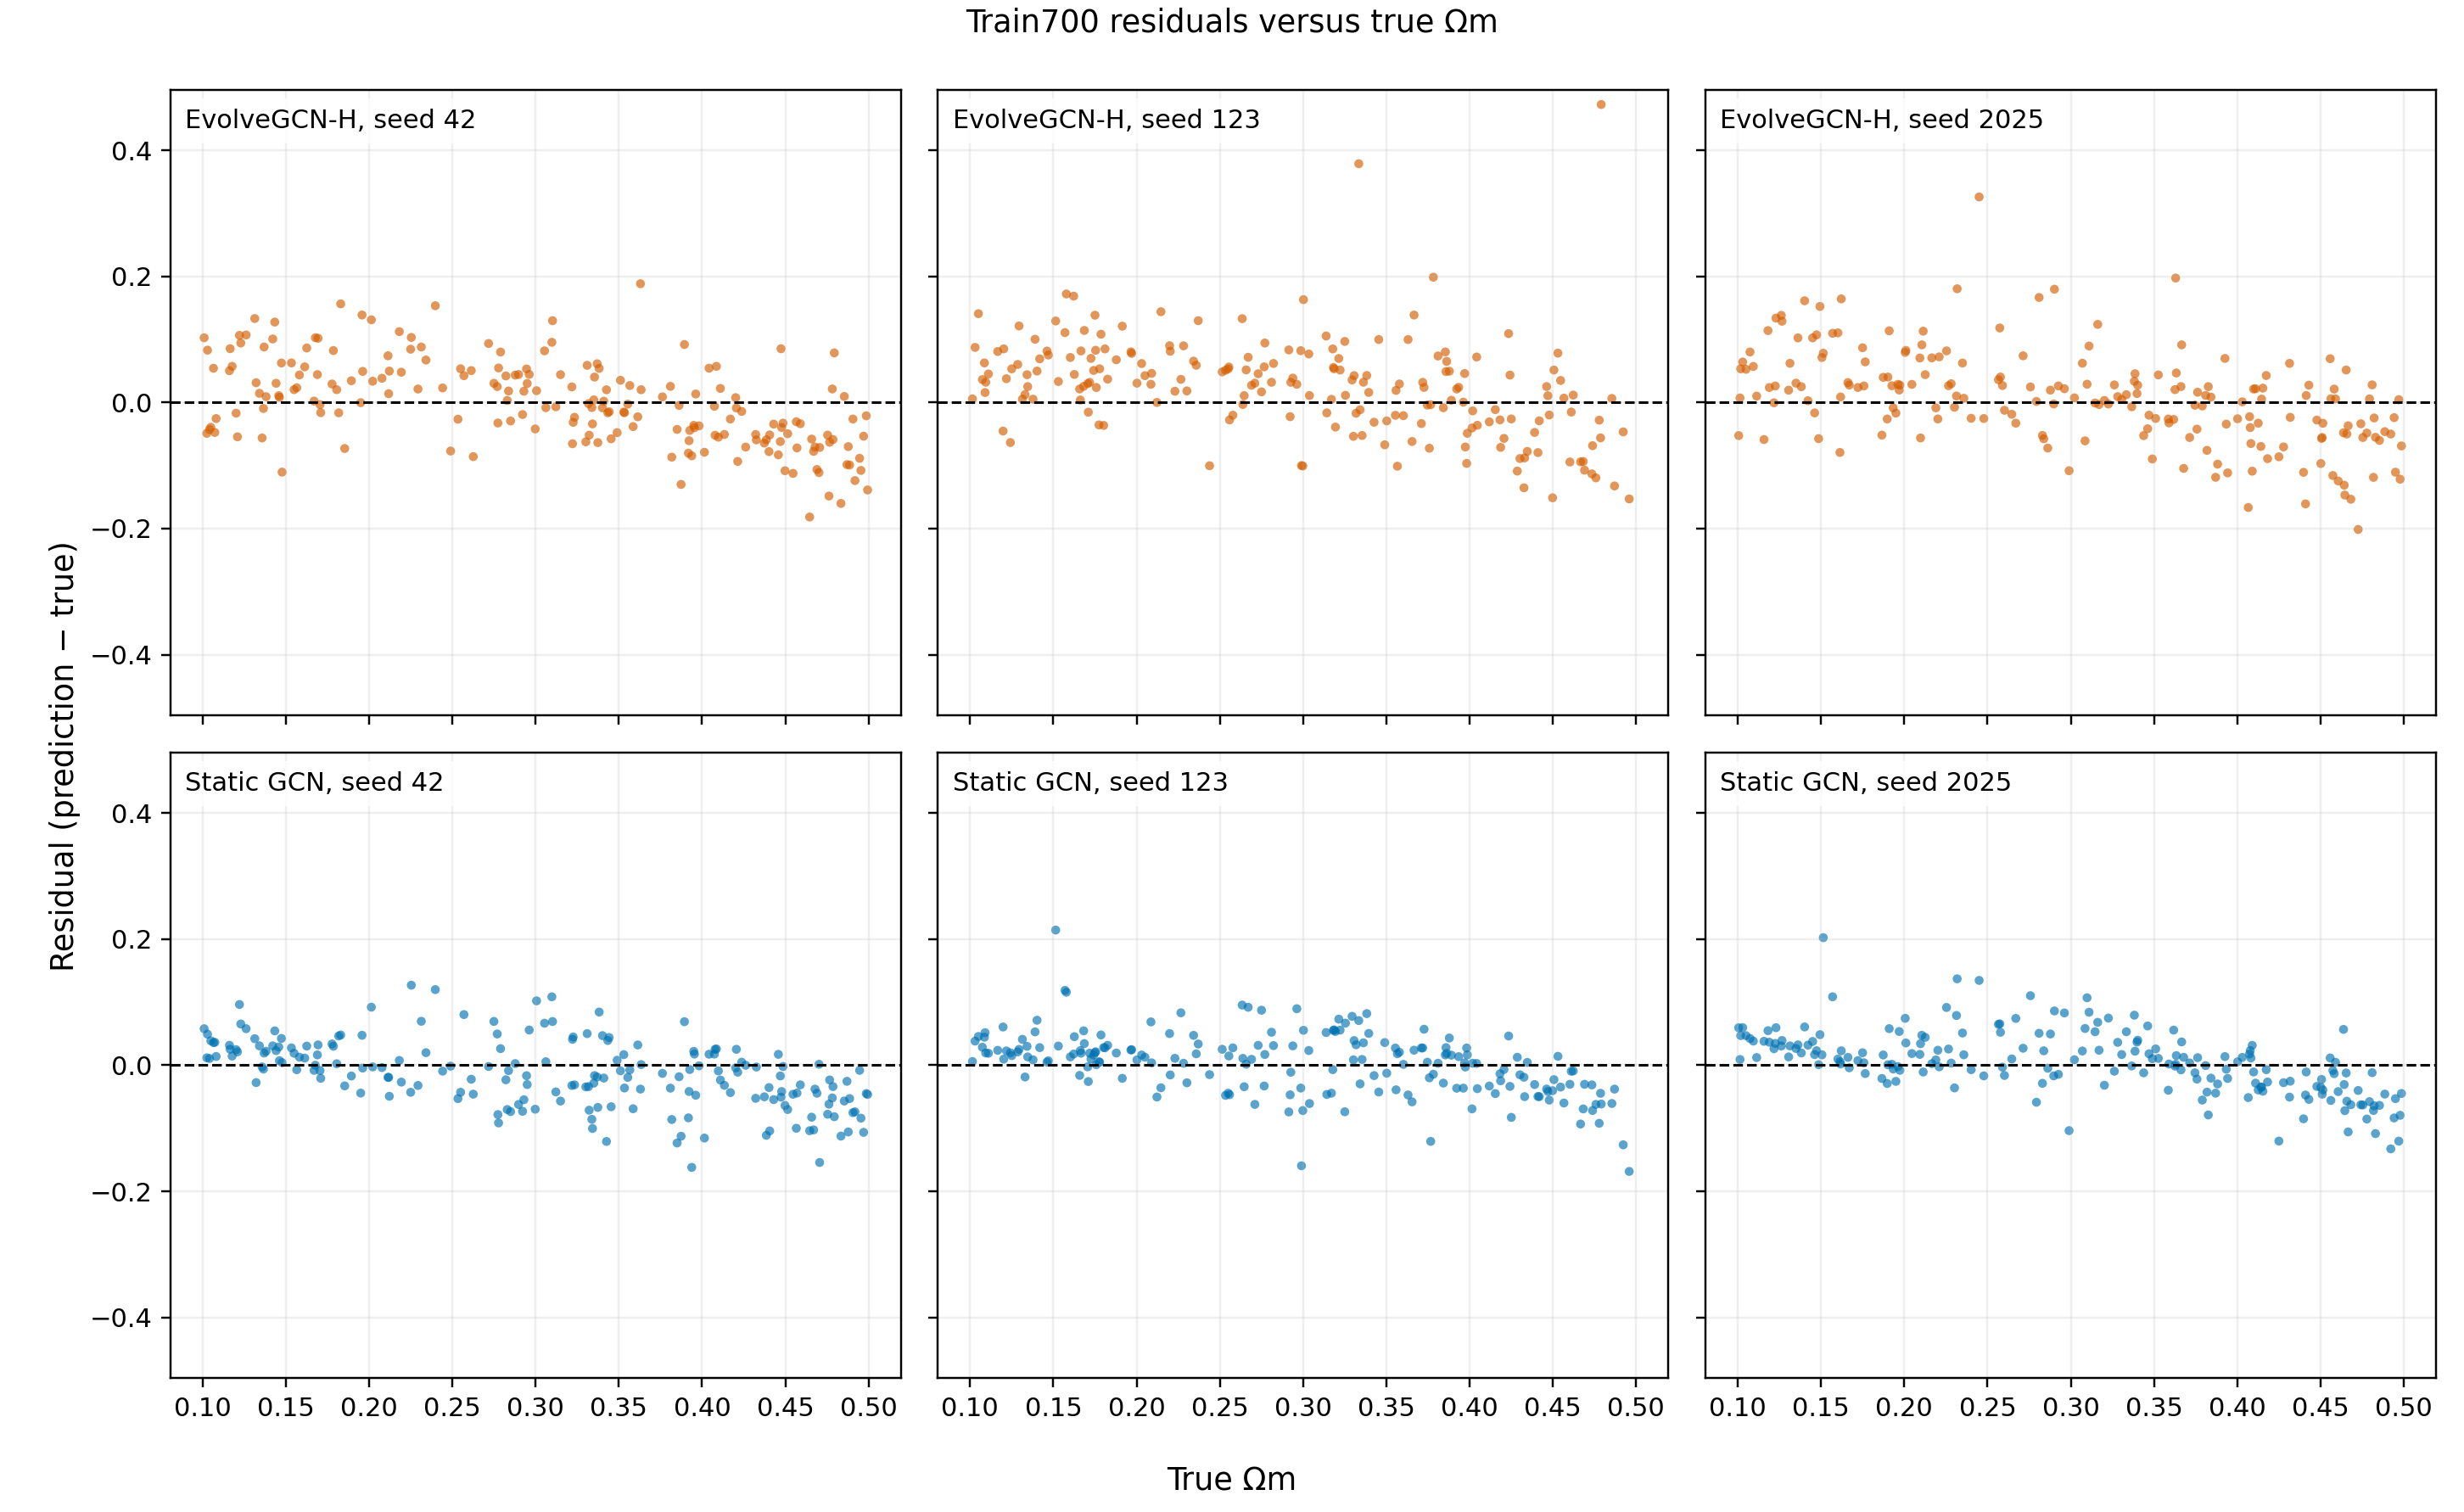

Model,Low-target bias,Middle-60% bias,High-target bias,Prediction-SD ratio
EvolveGCN-H,0.0478 ± 0.0109,0.0183 ± 0.0143,-0.0501 ± 0.0164,0.888 ± 0.075
Static GCN,0.0302 ± 0.0053,0.0036 ± 0.0125,-0.0502 ± 0.0091,0.855 ± 0.025


In [15]:
show_figure(ASSET_DIR / '08_train700_residual_vs_true.png', 'Train700 residual versus true Ωm; the zero line marks unbiased prediction.', width=1020)
bias = summary.query('training_count == 700').copy()
bias_table = pd.DataFrame({
    'Model': bias['model'],
    'Low-target bias': bias.apply(lambda r: f"{r.lowest_quintile_bias_mean:.4f} ± {r.lowest_quintile_bias_sample_std:.4f}", axis=1),
    'Middle-60% bias': bias.apply(lambda r: f"{r.middle_60_percent_bias_mean:.4f} ± {r.middle_60_percent_bias_sample_std:.4f}", axis=1),
    'High-target bias': bias.apply(lambda r: f"{r.highest_quintile_bias_mean:.4f} ± {r.highest_quintile_bias_sample_std:.4f}", axis=1),
    'Prediction-SD ratio': bias.apply(lambda r: f"{r.prediction_sd_ratio_mean:.3f} ± {r.prediction_sd_ratio_sample_std:.3f}", axis=1),
})
show_table(bias_table, caption='Train700 target-range bias and prediction spread (mean ± sample SD)')

At Train700, both models have prediction-SD ratios below one and show positive low-target bias with negative high-target bias. They do **not** completely collapse: both discriminate targets and attain positive R². They do retain partial compression.

# 14 — Paired Static versus Evolve Comparison

Training universes,Seed,Static MAE,Evolve MAE,Static − Evolve MAE,Winner
20,42,0.06977,0.24119,-0.17142,Static GCN
20,123,0.06264,1.11262,-1.04998,Static GCN
20,2025,0.07379,0.27441,-0.20062,Static GCN
50,42,0.05756,0.12477,-0.06721,Static GCN
50,123,0.06432,0.29558,-0.23126,Static GCN
50,2025,0.05279,0.10976,-0.05697,Static GCN
100,42,0.04957,0.08922,-0.03964,Static GCN
100,123,0.05110,0.31756,-0.26646,Static GCN
100,2025,0.05119,0.08596,-0.03477,Static GCN
200,42,0.04811,0.07151,-0.02341,Static GCN


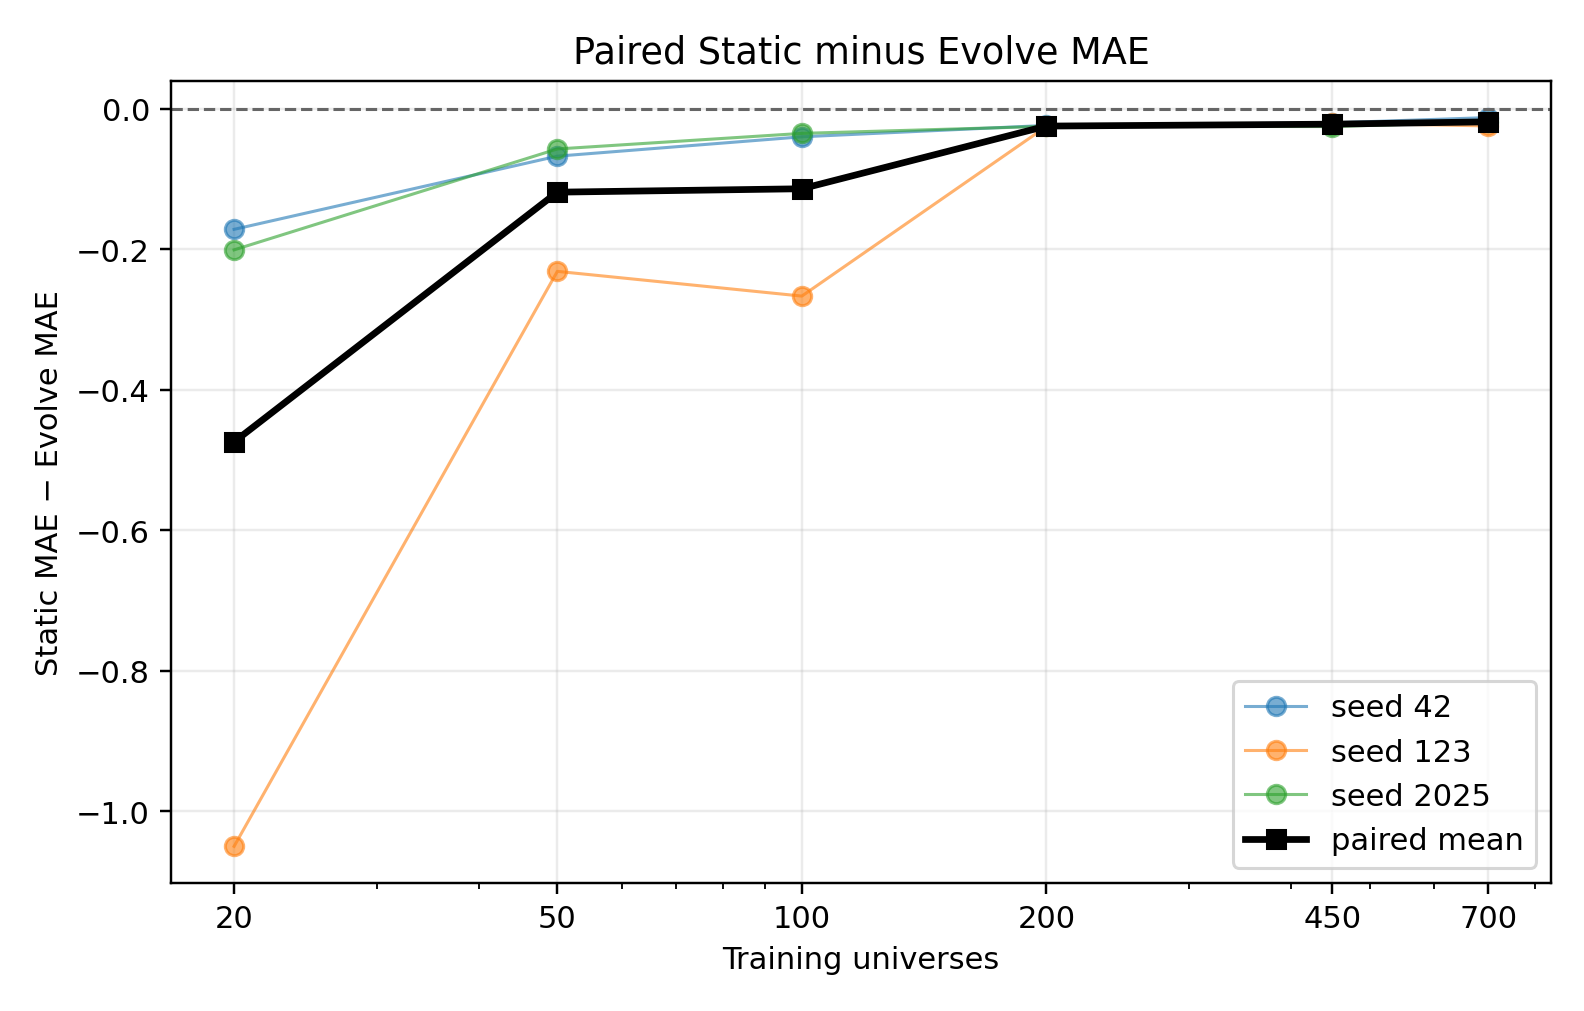

In [16]:
paired_display = paired.copy()
paired_display['Winner'] = np.where(paired_display.static_minus_evolve_mae < 0, 'Static GCN', 'EvolveGCN-H')
show_table(paired_display, ['training_count','seed','static_mae','evolve_mae','static_minus_evolve_mae','Winner'],
           {'training_count':'Training universes','seed':'Seed','static_mae':'Static MAE','evolve_mae':'Evolve MAE',
            'static_minus_evolve_mae':'Static − Evolve MAE'}, precision=5,
           caption='Seed-matched MAE comparisons; negative difference favors Static')
show_figure(ASSET_DIR / '09_static_minus_evolve_mae.png', 'Static MAE minus Evolve MAE for all 18 matched cells; all values are below zero.', width=980)

Static GCN achieved lower MAE in **all 18 seed-matched comparisons**. This is stronger than comparing unrelated best runs because both models share the same 201 named test universes inside every matched seed and training level.

# 15 — Train450 versus Train700

Model,Seed,Train450 MAE,Train700 MAE,Train700 − Train450 MAE
EvolveGCN-H,42,0.06609,0.05544,-0.01065
EvolveGCN-H,123,0.05897,0.06177,0.00280
EvolveGCN-H,2025,0.06627,0.05672,-0.00955
Static GCN,42,0.04629,0.04318,-0.00311
Static GCN,123,0.03891,0.03762,-0.00129
Static GCN,2025,0.04120,0.03822,-0.00298


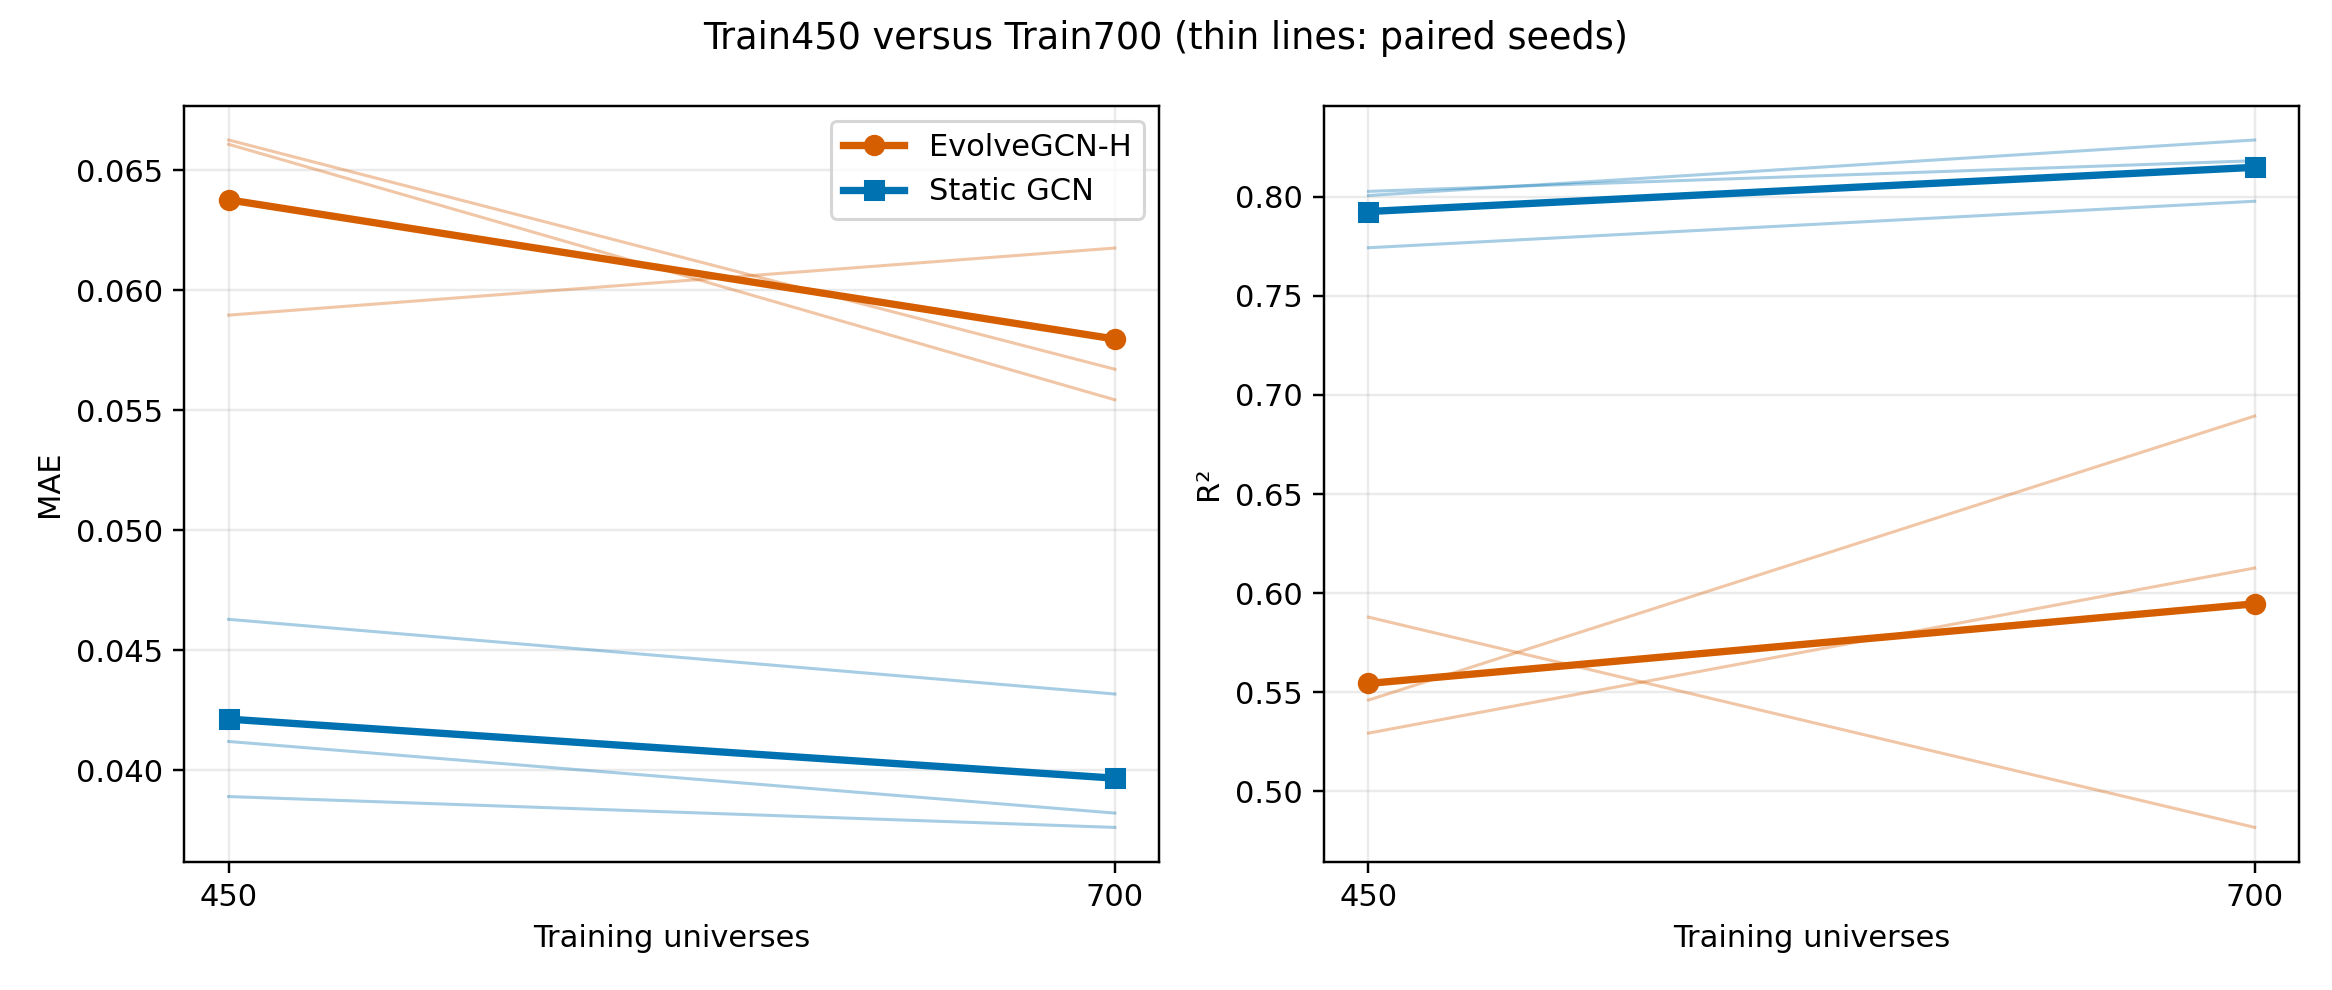

In [17]:
show_table(train_compare, ['model','seed','train450_mae','train700_mae','train700_minus_train450_mae'],
           {'model':'Model','seed':'Seed','train450_mae':'Train450 MAE','train700_mae':'Train700 MAE',
            'train700_minus_train450_mae':'Train700 − Train450 MAE'}, precision=5,
           caption='Paired final scaling step; negative change is improvement')
show_figure(ASSET_DIR / '10_train450_vs_train700.png', 'Train450 versus Train700 paired MAE by model and seed.', width=980)

In [18]:
late = train_compare.groupby('model')['train700_minus_train450_mae'].agg(['mean','std']).reset_index()
late['Improved seeds'] = train_compare.assign(improved=train_compare.train700_minus_train450_mae < 0).groupby('model').improved.sum().values
late['Mean change'] = late.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
show_table(late, ['model','Mean change','Improved seeds'], {'model':'Model'}, caption='Train700 − Train450 MAE, mean ± sample SD across paired seeds')

Model,Mean change,Improved seeds
EvolveGCN-H,-0.0058 ± 0.0075,2
Static GCN,-0.0025 ± 0.0010,3


Train450 uses 450 train + 99 validation + 201 test, leaving 250 unused. Train700 uses the full U1000 accounting with none unused. Static improves in all three seeds; Evolve improves in two of three. The late gains are smaller than the full scaling gain, consistent with **diminishing returns**, but the evidence does not establish complete saturation.

# 16 — Scientific Diagnosis

In [19]:
diagnosis = pd.DataFrame([
    ('No learnable signal', 'Both models improve; positive Train700 R²', 'Residual structure and nonzero error remain', 'Rejected'),
    ('Insufficient training data', 'Large early errors; scaling helps', 'Architecture gap remains at Train700', 'Contributes, not the full explanation'),
    ('Complete mean collapse', 'Compression is visible', 'Train700 SD ratios ≈0.86–0.89 and positive R²', 'Rejected at larger sizes'),
    ('Evolve optimization instability', 'Extreme Train20 seed variability; unstable through Train100', 'Reliable three-seed results near Train200', 'Supported in low-data regime'),
    ('Static architecture better matched', 'Wins all 18 pairs; smoother and more sample-efficient', 'Only one tested protocol/implementation', 'Supported under this protocol'),
    ('Temporal information inherently unhelpful', 'Tested temporal model is worse', 'Architectures/readouts/optimization differ; no temporal isolation', 'Not established'),
], columns=['Hypothesis','Evidence for','Evidence against','Conclusion'])
show_table(diagnosis, caption='Evidence-weighted diagnosis')

Hypothesis,Evidence for,Evidence against,Conclusion
No learnable signal,Both models improve; positive Train700 R²,Residual structure and nonzero error remain,Rejected
Insufficient training data,Large early errors; scaling helps,Architecture gap remains at Train700,"Contributes, not the full explanation"
Complete mean collapse,Compression is visible,Train700 SD ratios ≈0.86–0.89 and positive R²,Rejected at larger sizes
Evolve optimization instability,Extreme Train20 seed variability; unstable through Train100,Reliable three-seed results near Train200,Supported in low-data regime
Static architecture better matched,Wins all 18 pairs; smoother and more sample-efficient,Only one tested protocol/implementation,Supported under this protocol
Temporal information inherently unhelpful,Tested temporal model is worse,Architectures/readouts/optimization differ; no temporal isolation,Not established


# 17 — Final Scientific Conclusion

Across **36 validated runs**, increasing the number of training universes improved both tested models overall. Static GCN was more stable and sample-efficient and achieved lower MAE in **all 18 seed-matched comparisons**. At Train700, Static reached approximately **0.0397 ± 0.0031 MAE**, compared with **0.0580 ± 0.0033** for EvolveGCN-H. Additional data alone therefore did not close the architecture gap. Both models retained some prediction compression, especially through overprediction of low targets and underprediction of high targets.

<div class="takeaway"><b>Thesis-ready conclusion.</b> Under the controlled U1000 Top1000 protocol, the tested Static GCN architecture used the available halo representation more effectively and consistently than the tested EvolveGCN-H architecture.</div>

This conclusion is architecture-specific. It does not establish that temporal information is useless.

# 18 — What This Phase Proved

<div class="callout"><b>Universe-count scaling is complete.</b><br><br>
It answered: “How many training universes are required for stable $\Omega_m$ prediction under the current representation?”<br><br>
• Static is stable even with relatively small training populations.<br>
• Evolve requires substantially more data and becomes reliable near Train200.<br>
• Both continue improving up to Train700.<br>
• Additional universe count alone does not solve the Evolve limitation.
</div>

# 19 — Transition to Notebook 12 / Next Phase

The next controlled experimental dimension is **halo-count scaling per snapshot**, potentially `Top1000`, `Top1500`, and `Top2000`, with larger values only after feasibility validation.

This changes the number of **halo nodes retained per snapshot**. It does not change the U1000 master population; Train700/validation99/test201 split; universe identities; five snapshots; target; graph protocol; or tested architectures.

> **Next hypothesis:** “Lower-mass halos excluded by Top1000 may contain additional distributional and structural information relevant to $\Omega_m$.”

Notebook 11 defines this transition but does not start or implement the experiment.

# Appendix A — Complete Split Identities

In [20]:
details = []
for seed in SEEDS:
    item = manifests[(seed,700)]
    role_blocks = []
    for role, label in [('train','Training (700)'),('val','Validation (99)'),('test','Test (201)')]:
        ids = item[f'{role}_ids']
        role_blocks.append(f'<h4>{label}</h4><div style="max-height:150px;overflow:auto;font-family:monospace">{escape(", ".join(ids))}</div>')
    details.append(f'<details><summary>Train700 · seed {seed} · full 1,000-universe provenance</summary>{"".join(role_blocks)}</details>')
display(HTML(''.join(details)))

In [21]:
all_details = []
for seed in SEEDS:
    for n in SIZES:
        item = manifests[(seed,n)]
        blocks = []
        for role, label in [('train','Training'),('val','Validation'),('test','Test'),('unused','Unused')]:
            ids = item[f'{role}_ids']
            blocks.append(f'<b>{label} ({len(ids)})</b><div style="max-height:110px;overflow:auto;font-family:monospace;margin-bottom:8px">{escape(", ".join(ids))}</div>')
        all_details.append(f'<details><summary>seed {seed} · Train{n} · {escape(f"seed{seed}_train{n}.json")}</summary>{"".join(blocks)}</details>')
display(HTML(''.join(all_details)))

# Appendix B — Additional True-versus-Predicted Figures

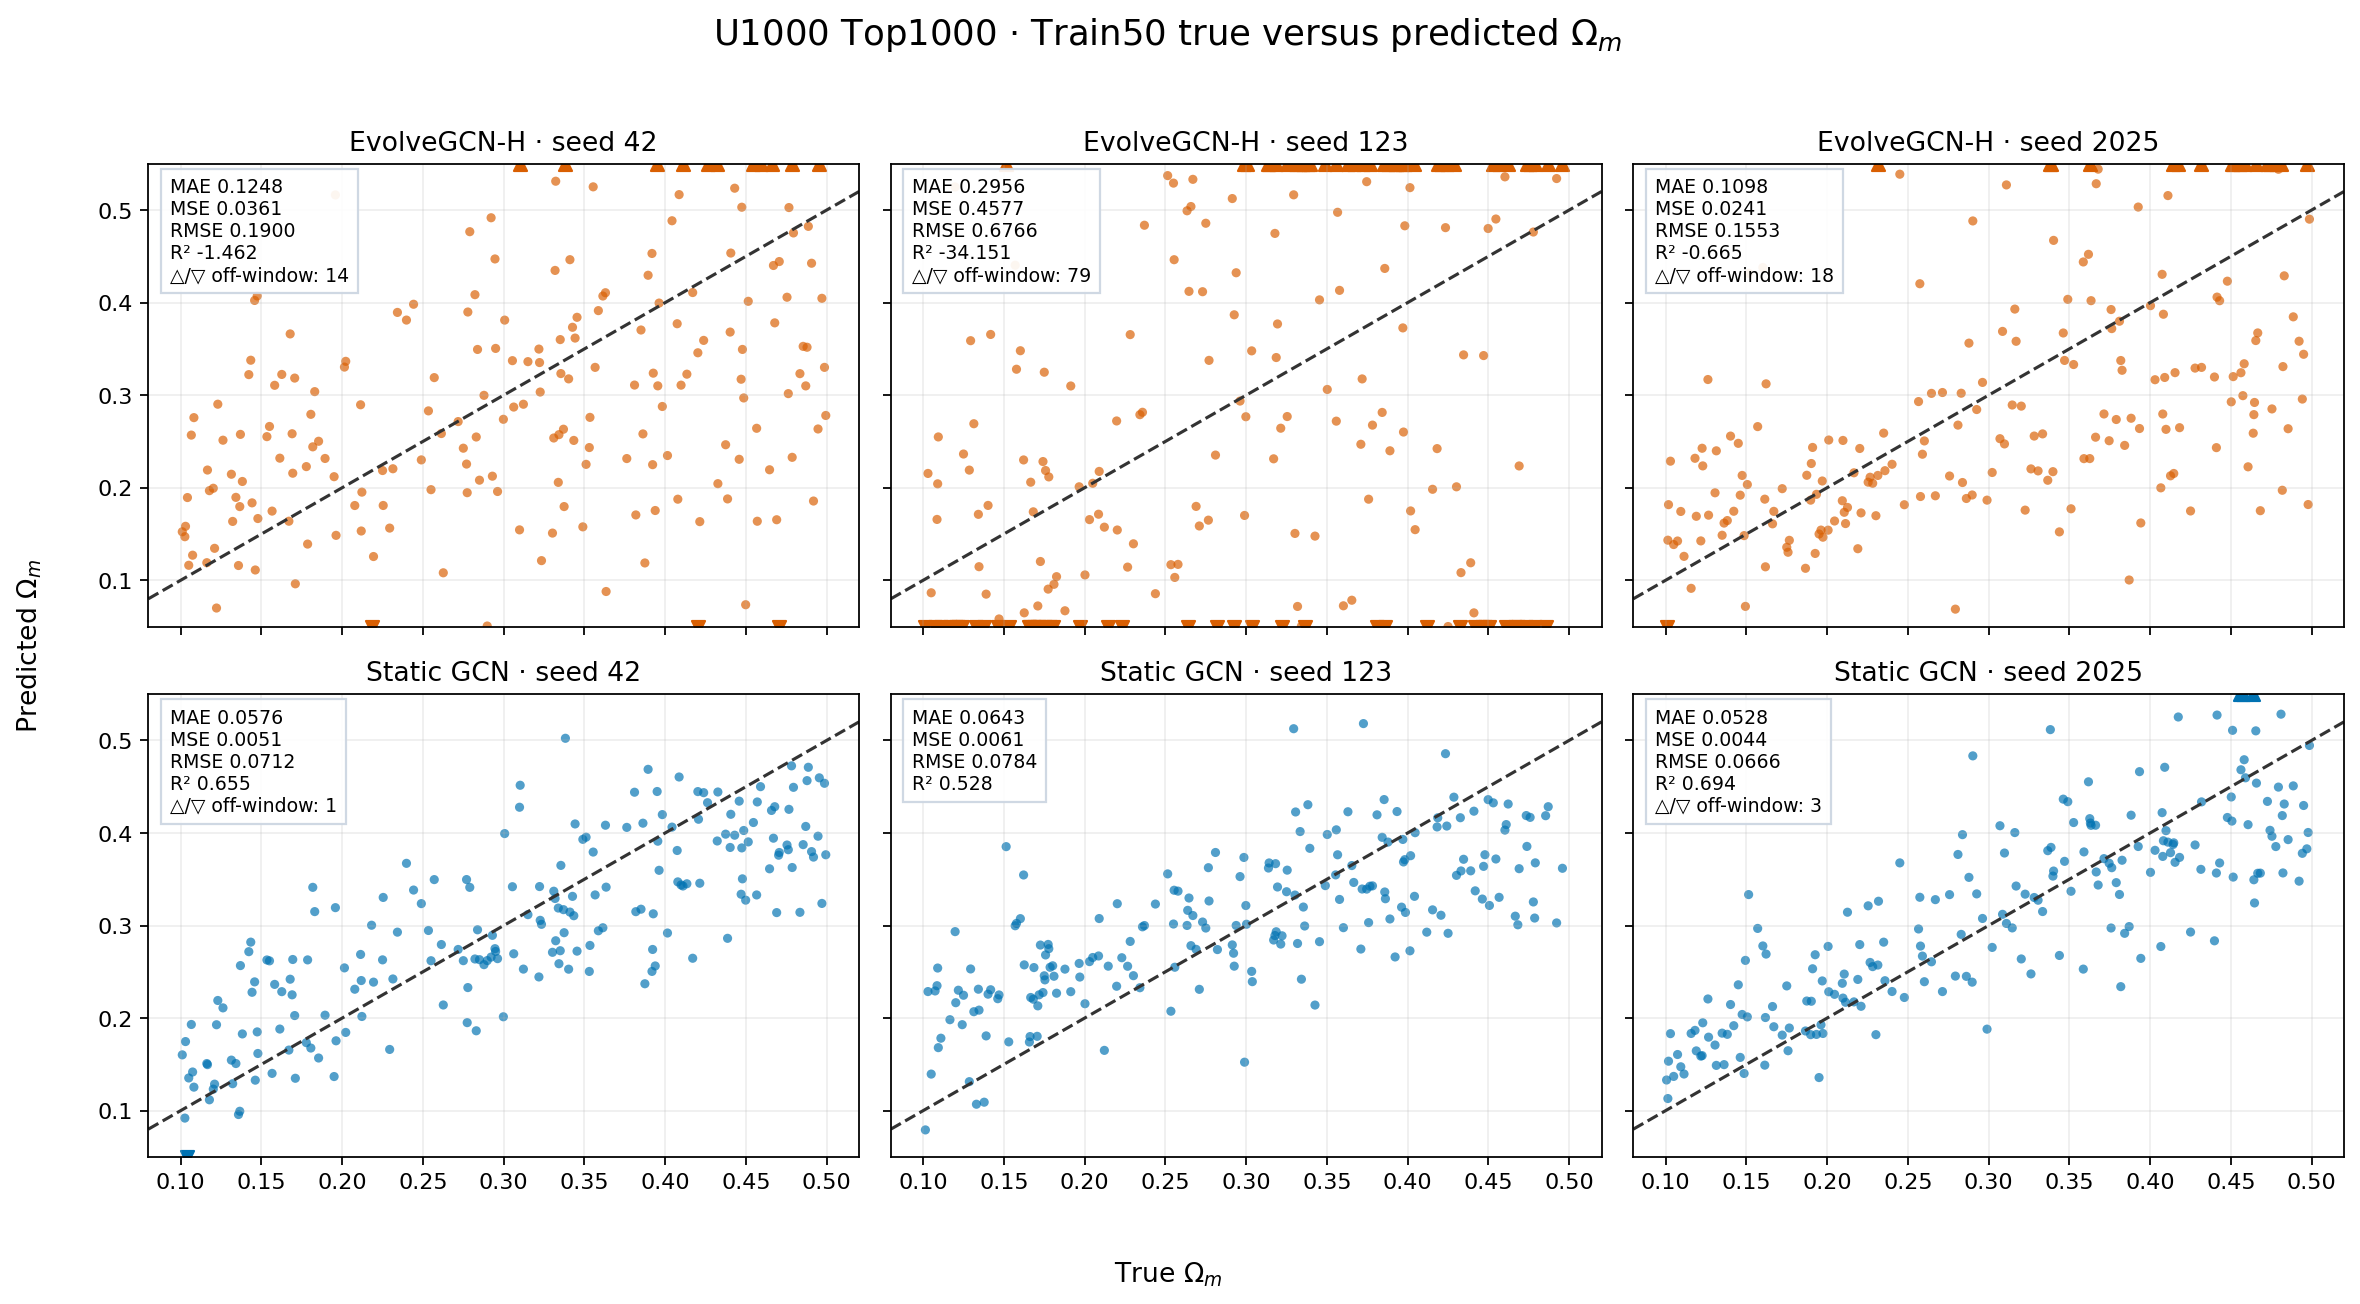

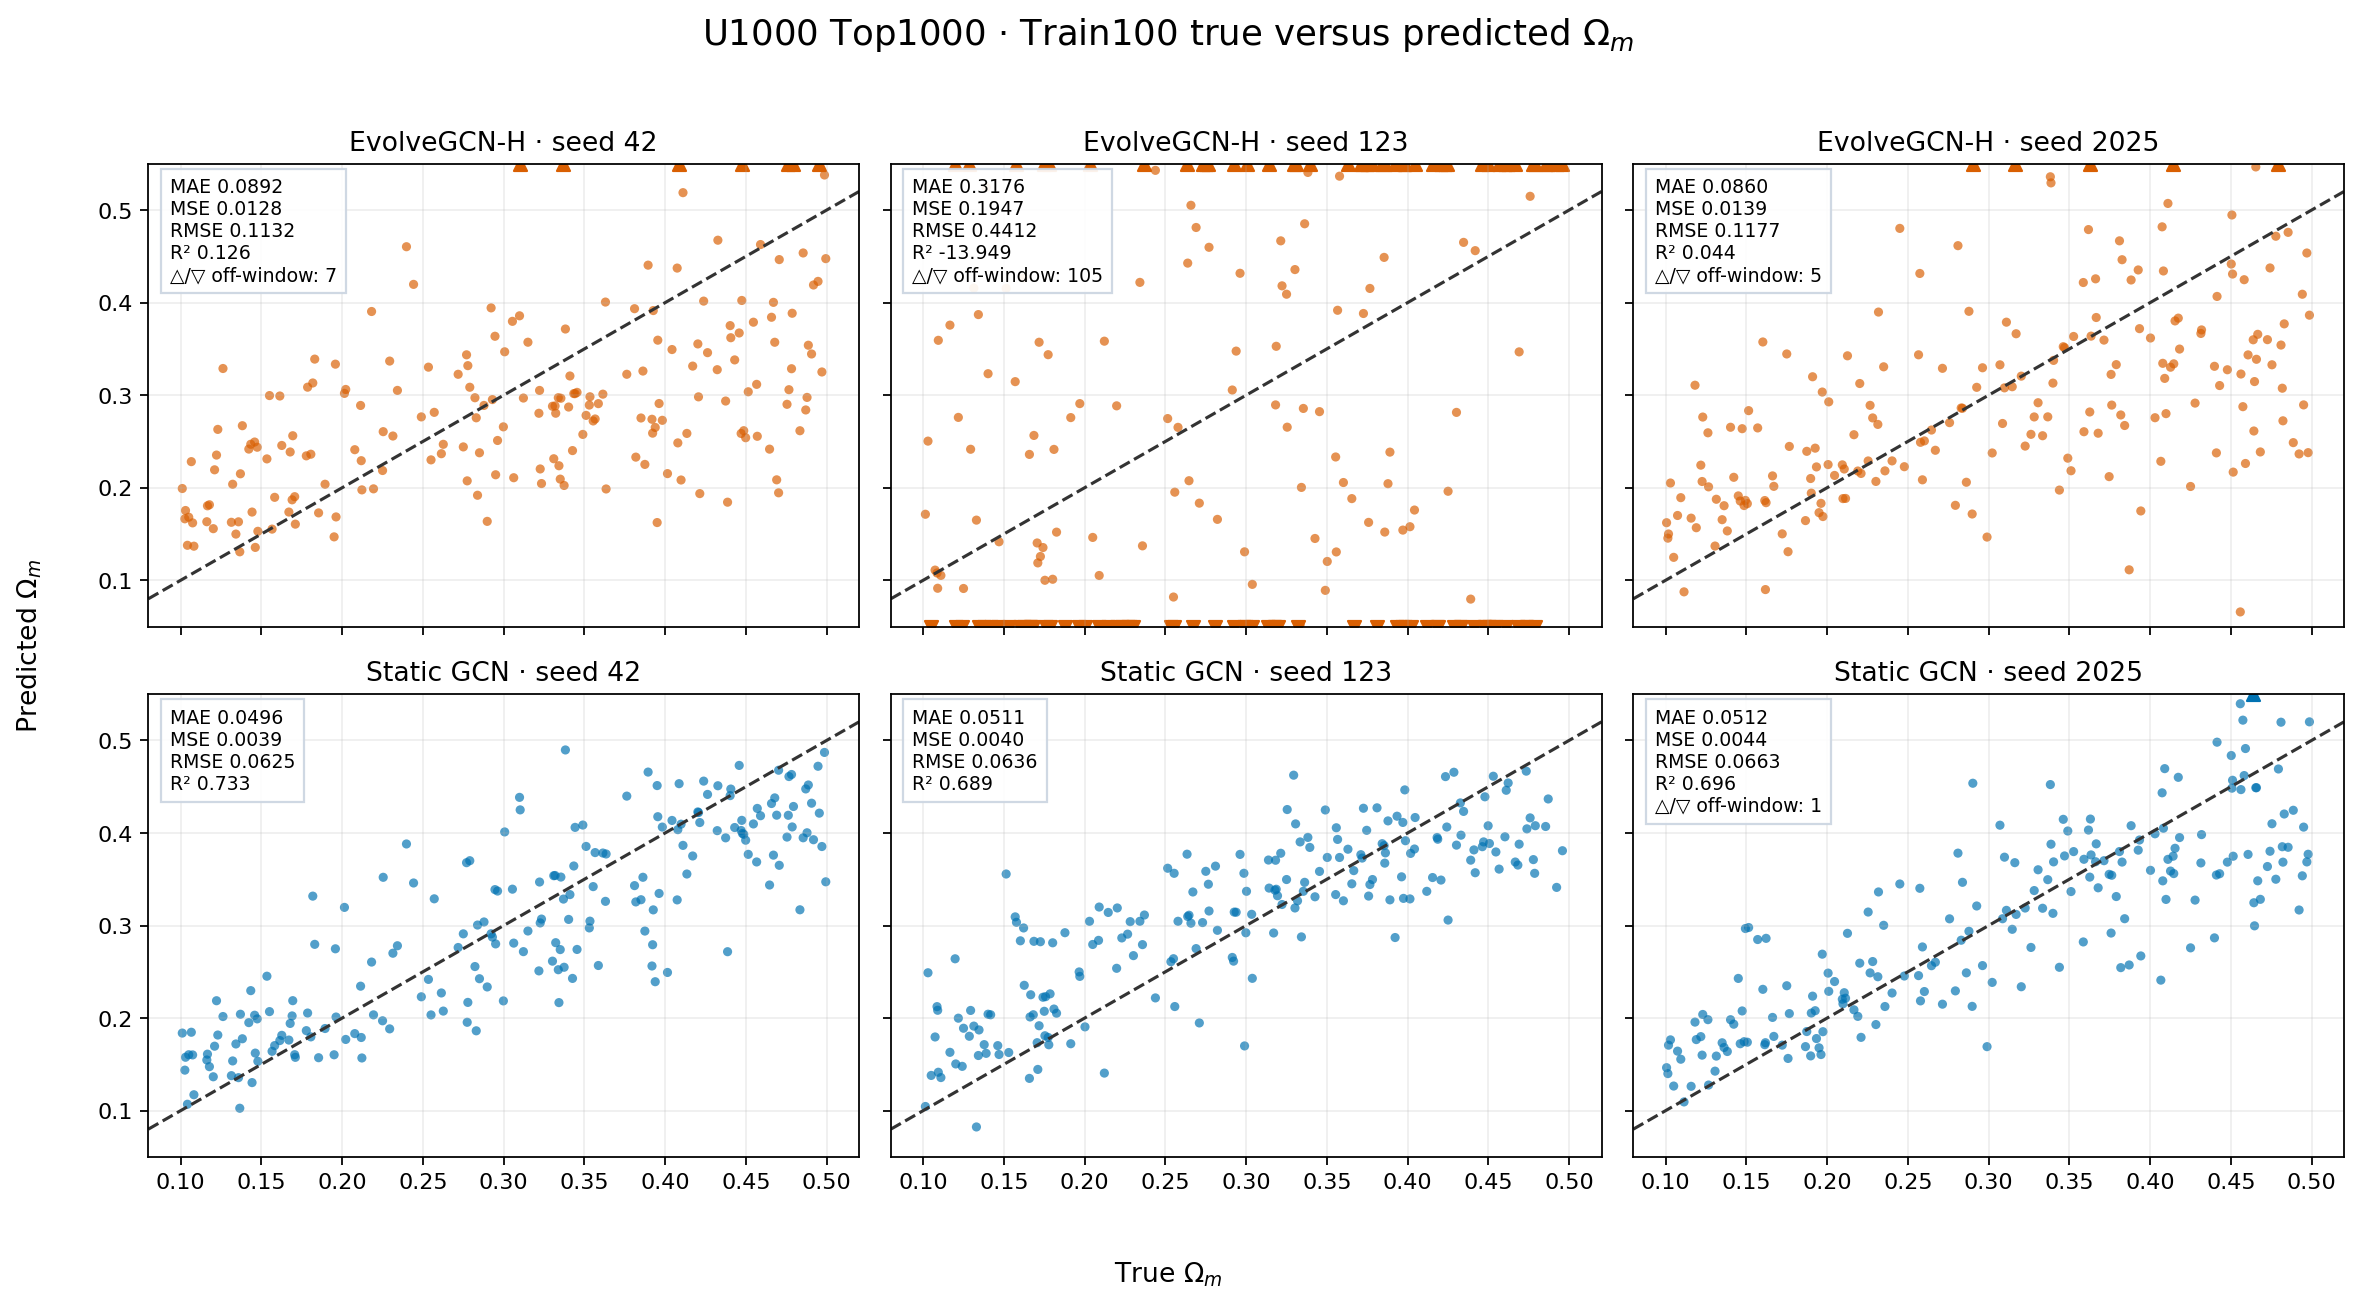

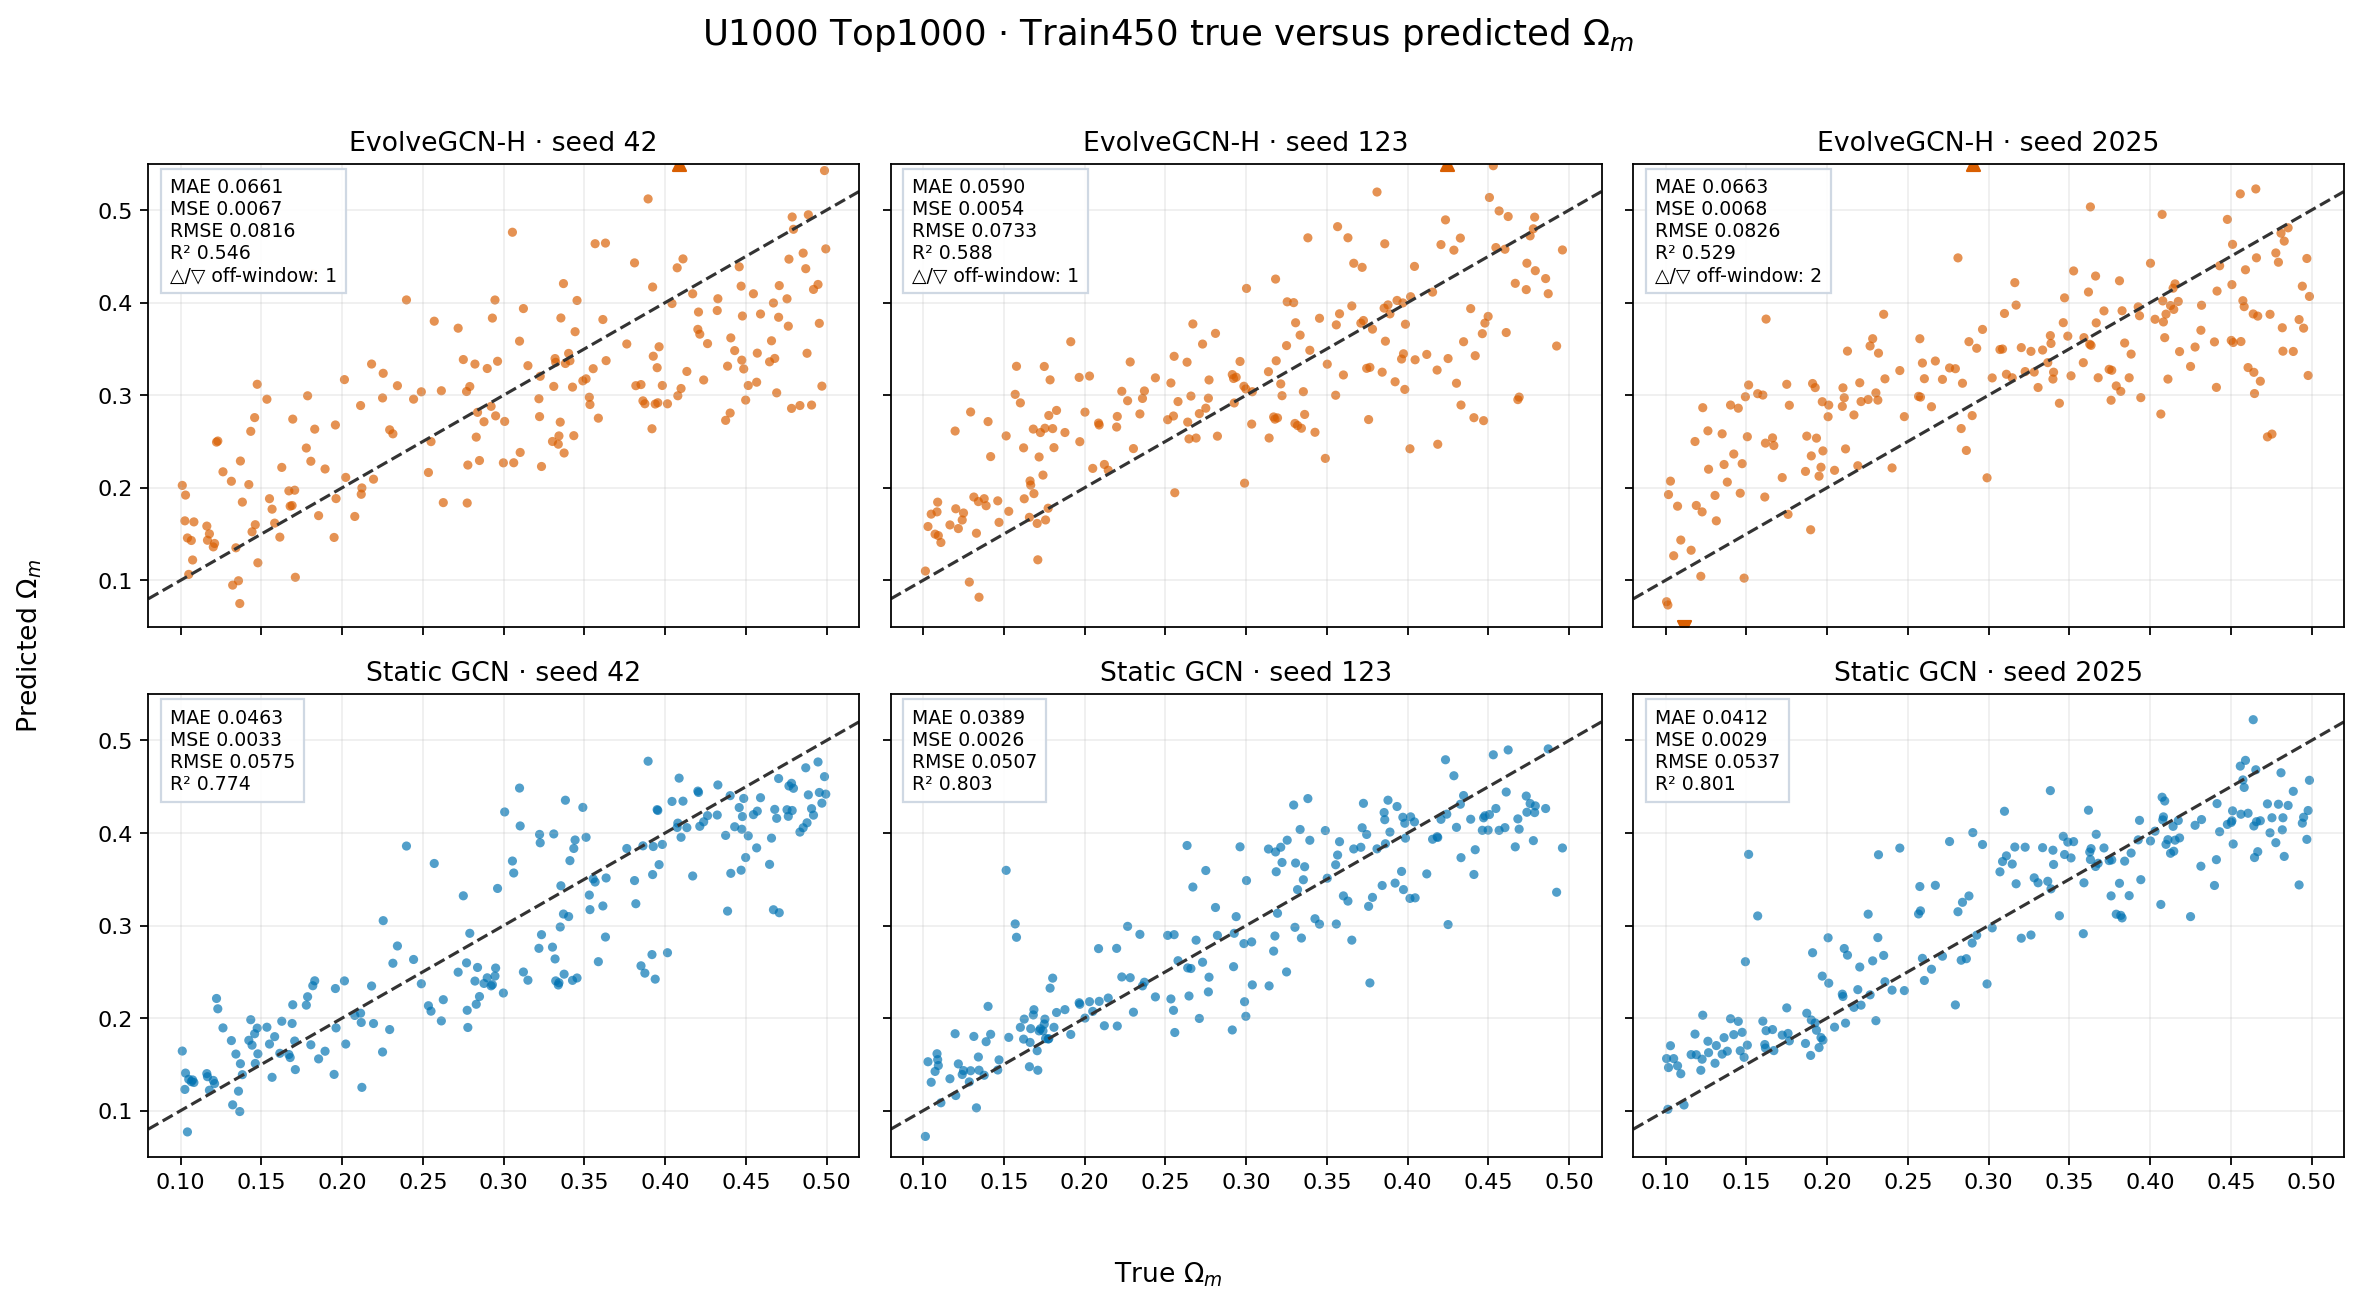

In [22]:
for size in [50, 100, 450]:
    show_figure(true_pred_paths[size], f'Appendix: Train{size} true versus predicted Ωm for both models and all seeds.', width=1050)

# Appendix C — Full Metrics and Prediction Tables

In [23]:
show_table(per_run, caption='Complete 36-run authoritative metric table', max_height=620)

model,training_count,seed,mae,mse,rmse,r2,prediction_mean,prediction_standard_deviation,true_target_standard_deviation,prediction_sd_ratio,residual_mean,residual_standard_deviation,lowest_quintile_mae,lowest_quintile_bias,middle_60_percent_mae,middle_60_percent_bias,highest_quintile_mae,highest_quintile_bias,best_epoch,runtime_seconds
EvolveGCN-H,20,42,0.2412,0.1438,0.3791,-8.8066,0.2524,0.3788,0.1214,3.1213,-0.0562,0.3759,0.1148,0.0504,0.2627,-0.0935,0.3052,-0.0545,204,197
EvolveGCN-H,20,123,1.1126,2.7403,1.6554,-209.4302,0.1420,1.6445,0.1144,14.3753,-0.1533,1.6524,0.4981,0.0547,1.1078,-0.0486,1.7413,-0.6653,170,182
EvolveGCN-H,20,2025,0.2744,0.1612,0.4015,-10.1236,0.3084,0.3917,0.1207,3.2455,0.0028,0.4025,0.2313,0.1490,0.2690,-0.0073,0.3333,-0.1141,76,105
EvolveGCN-H,50,42,0.1248,0.0361,0.1900,-1.4619,0.3113,0.1959,0.1214,1.6137,0.0027,0.1904,0.0905,0.0851,0.1139,-0.0008,0.1905,-0.0696,40,99
EvolveGCN-H,50,123,0.2956,0.4577,0.6766,-34.1514,0.3341,0.6976,0.1144,6.0983,0.0388,0.6771,0.1725,-0.0298,0.2351,0.0471,0.5943,0.0833,111,166
EvolveGCN-H,50,2025,0.1098,0.0241,0.1553,-0.6649,0.3039,0.1771,0.1207,1.4674,-0.0017,0.1557,0.0708,0.0544,0.0989,-0.0108,0.1804,-0.0312,37,94
EvolveGCN-H,100,42,0.0892,0.0128,0.1132,0.1260,0.2924,0.1090,0.1214,0.8978,-0.0163,0.1123,0.0679,0.0671,0.0799,-0.0165,0.1376,-0.0988,60,166
EvolveGCN-H,100,123,0.3176,0.1947,0.4412,-13.9491,0.2663,0.4439,0.1144,3.8804,-0.0290,0.4414,0.1854,0.0580,0.2835,-0.0222,0.5486,-0.1359,101,218
EvolveGCN-H,100,2025,0.0860,0.0139,0.1177,0.0442,0.2957,0.1158,0.1207,0.9593,-0.0099,0.1176,0.0698,0.0619,0.0762,0.0029,0.1304,-0.1187,44,140
EvolveGCN-H,200,42,0.0715,0.0091,0.0954,0.3795,0.3193,0.1148,0.1214,0.9460,0.0107,0.0950,0.0776,0.0725,0.0606,0.0088,0.0970,-0.0458,74,270


In [24]:
full_prediction_details = []
for model in MODELS:
    for seed in SEEDS:
        table = prediction_cache[(model,700,seed)][['universe_id','true_omega_m','pred_omega_m','residual','absolute_error']].copy()
        full_prediction_details.append(
            f'<details><summary>{escape(model)} · Train700 · seed {seed} — all 201 test universes</summary>' +
            f'<div style="max-height:420px;overflow:auto">{table.to_html(index=False, float_format=lambda x: f"{x:.6f}")}</div></details>'
        )
display(HTML(''.join(full_prediction_details)))

universe_id,true_omega_m,pred_omega_m,residual,absolute_error
LH_21,0.134200,0.148688,0.014488,0.014488
LH_346,0.333800,0.325714,-0.008086,0.008086
LH_703,0.177800,0.207068,0.029268,0.029268
LH_230,0.103000,0.185920,0.082920,0.082920
LH_253,0.279000,0.358964,0.079964,0.079964
LH_123,0.294600,0.347721,0.053121,0.053121
LH_462,0.295000,0.325090,0.030090,0.030090
LH_529,0.485400,0.494969,0.009569,0.009569
LH_448,0.277400,0.244831,-0.032569,0.032569
LH_590,0.331000,0.389918,0.058918,0.058918


# Appendix D — Runtime and Optimization Details

In [25]:
runtime = per_run[['model','training_count','seed','best_epoch','runtime_seconds']].copy()
show_table(runtime, rename={'model':'Model','training_count':'Training universes','seed':'Seed','best_epoch':'Best epoch','runtime_seconds':'Runtime (s)'},
           caption='Run-level best epoch and runtime', max_height=580)

Model,Training universes,Seed,Best epoch,Runtime (s)
EvolveGCN-H,20,42,204,197
EvolveGCN-H,20,123,170,182
EvolveGCN-H,20,2025,76,105
EvolveGCN-H,50,42,40,99
EvolveGCN-H,50,123,111,166
EvolveGCN-H,50,2025,37,94
EvolveGCN-H,100,42,60,166
EvolveGCN-H,100,123,101,218
EvolveGCN-H,100,2025,44,140
EvolveGCN-H,200,42,74,270


# Appendix E — Reproducibility Audit

In [26]:
paired_manifest_check = run_matrix.groupby(['seed','training_universe_count'])['split_manifest_path'].nunique()
audit = pd.DataFrame([
    ('Required authoritative inputs resolve', all(path.is_file() for path in required.values())),
    ('36 completed/PASS runs', len(run_matrix) == 36),
    ('18 rows per model', run_matrix.groupby('model').size().eq(18).all()),
    ('Six training levels', set(run_matrix.training_universe_count) == set(SIZES)),
    ('Three seeds', set(run_matrix.seed) == set(SEEDS)),
    ('18 immutable manifests', len(manifest_paths) == 18),
    ('Exact split counts and disjointness', True),
    ('Nested training subsets', True),
    ('Train700 accounts for LH_0…LH_999', True),
    ('Matched models use identical manifests', paired_manifest_check.eq(1).all()),
    ('Invalid experiment excluded', not run_matrix.canonical_experiment_id.str.contains('invalid', case=False).any()),
    ('All six true-vs-predicted figures resolve', all(path.is_file() for path in true_pred_paths.values())),
    ('All presentation figures resolve', all((ASSET_DIR / name).is_file() for name, _ in curve_assets)),
    ('No training code invoked', True),
], columns=['Check','Pass'])
if not audit['Pass'].all(): raise RuntimeError('Notebook audit failed')
show_table(audit, caption='Notebook execution and scientific-integrity checks')
display(Markdown(
    f'**Source provenance**  \n- Current source commit: `{SOURCE_COMMIT}`  \n'
    f'- Analysis commit: `{ANALYSIS_COMMIT}`  \n'
    '- Template: `notebooks/visualization/10_final_experiment_report.ipynb`  \n'
    '- No training, graph-dataset build/load, checkpoint load, or source-artifact write occurred.'
))

Check,Pass
Required authoritative inputs resolve,Yes
36 completed/PASS runs,Yes
18 rows per model,Yes
Six training levels,Yes
Three seeds,Yes
18 immutable manifests,Yes
Exact split counts and disjointness,Yes
Nested training subsets,Yes
Train700 accounts for LH_0…LH_999,Yes
Matched models use identical manifests,Yes


**Source provenance**  
- Current source commit: `3cd330e8b27cccd11912be12c802598fcb1a3ee7`  
- Analysis commit: `3cd330e8b27cccd11912be12c802598fcb1a3ee7`  
- Template: `notebooks/visualization/10_final_experiment_report.ipynb`  
- No training, graph-dataset build/load, checkpoint load, or source-artifact write occurred.